# **Federated Multi Knowledge Distillation Learning (FedMultKD)**

## **Importing Relevant Libraries**

In [382]:
import tensorflow as tf
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'),
 PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]

In [383]:
import pandas as pd
import random
import cv2
import os.path
from PIL import Image
from skimage.io import imread, imsave, imshow, show, imread_collection, imshow_collection
import os
import glob
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow import keras
import logging
#tf.config.set_visible_devices([], 'GPU')
from sklearn import preprocessing
tf.get_logger().setLevel(logging.ERROR)
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras import backend as K
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import time
from sklearn.preprocessing import MinMaxScaler
import tensorflow_federated as tff

In [384]:
'''
##### Training Teacher Model (Deep-COVID)
M. Ghaderzadeh, F. Asadi, R. Jafari, D. Bashash, H. Abolghasemi, and M. Aria. Deep
convolutional neural network–based computer-aided detection system for covid-19 using mul-
tiple lung scans: Design and implementation study. J Med Internet Res, 23:e27468, 2021,4.
http://www.ncbi.nlm.nih.gov/pubmed/33848973
'''
IMAGE_SIZE = 200
SEED = 7
os.environ['PYTHONHASHSEED']=str(SEED)
np.random.seed(SEED)
random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
import tensorflow.keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Activation, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers.experimental import preprocessing
import tensorflow.keras.backend as K

from tensorflow.keras.applications import NASNetLarge
NETWORK = NASNetLarge

#from kaggle_datasets import KaggleDatasets

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, mean_squared_error, classification_report


import re
import imageio
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
%matplotlib inline
try:
    tpu = None
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print('Device:', tpu.master())
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)

    strategy = tf.distribute.experimental.TPUStrategy(tpu)
except:
    strategy = tf.distribute.get_strategy()
print('Number of replicas:', strategy.num_replicas_in_sync)

print("Tensorflow version ", tf.__version__)

from tensorflow.keras.callbacks import Callback
class CosineAnnealingScheduler(Callback):

    def __init__(self, T_max, eta_max, eta_min=0, verbose=0):
        super(CosineAnnealingScheduler, self).__init__()
        self.T_max = T_max
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose

    def on_epoch_begin(self, epoch, logs=None):
        if not hasattr(self.model.optimizer, 'lr'):
            raise ValueError('Optimizer must have a "lr" attribute.')
        lr = self.eta_min + (self.eta_max - self.eta_min) * (1 + math.cos(math.pi * epoch / self.T_max)) / 2
        K.set_value(self.model.optimizer.lr, lr)
        if self.verbose > 0:
            print('\nEpoch %05d: CosineAnnealingScheduler setting learning '
                  'rate to %s.' % (epoch + 1, lr))

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = K.get_value(self.model.optimizer.lr)

image_size = 200
img_augmentation = keras.Sequential(
    [
        tf.keras.layers.Normalization(),
        tf.keras.layers.Resizing(image_size, image_size),
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(factor=0.02),
        tf.keras.layers.RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
    ],
    name="Augmentation",
)
#img_augmentation.layers[0].adapt(train_features_dataset2)

AUTOTUNE = tf.data.experimental.AUTOTUNE
tf.config.optimizer.set_jit(True)

# dataset_id1 = 'covid19-lung-ct-scans'
# #GCS_PATH1 = KaggleDatasets().get_gcs_path(dataset_id1)
BATCH_SIZE = 128 * strategy.num_replicas_in_sync

CLASSES = ['COVID-19', 'Non-COVID-19']
NUM_CLASSES = len(CLASSES)
IMAGE_SIZE_ = [IMAGE_SIZE, IMAGE_SIZE]#224, 224
input_shape = (IMAGE_SIZE, IMAGE_SIZE, 1)#224, 224, 3
LOSS = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2)

METRICS = ['accuracy']

Epochs = 50
Early_Stop = 15
OPTIMIZER = tensorflow.keras.optimizers.legacy.Adam(lr = 1e-2, decay = 1e-4)

Fine_Tune_Epochs = 100
Fine_Tune_Early_Stop = 20
Fine_Tune_OPTIMIZER = tensorflow.keras.optimizers.legacy.Adam(lr = 1e-3, decay = 1e-6)
Fine_Tune_filepath = "Best-Model-FT.h5"

Callbacks = [
    CosineAnnealingScheduler(Epochs, 1e-3, 1e-6),
    EarlyStopping(monitor='val_accuracy', patience=Early_Stop, mode='auto', min_delta=0.00001, verbose=2, restore_best_weights=True)]

FT_Callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=5, verbose=2, mode='min', min_delta=0.0001, cooldown=1, min_lr=1e-6),
    ModelCheckpoint(Fine_Tune_filepath, monitor='val_accuracy', verbose=2, save_best_only=True, save_weights_only=False, mode='max'),
    EarlyStopping(monitor='val_loss', patience=Fine_Tune_Early_Stop, mode='auto', min_delta=0.00001, verbose=2, restore_best_weights=True)]

from tensorflow.keras.layers import Lambda
input_tensor = Input(shape=input_shape)
input_rgb = Lambda(lambda x: K.repeat_elements(x, 3, axis=-1))(input_tensor)



Number of replicas: 1
Tensorflow version  2.14.1


/home/maxwellsam/Compression_Model_FL_MTKD/.FL_MTKD/lib/python3.11/site-packages/keras/src/optimizers/legacy/adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [385]:
import seaborn as sns
def getCorrectLabel(x):
        if x == 0:
            return 'Non-Covid'
        if x == 1:
            return 'Covid'

def D1_to_D2(y_pred):
    y_true = {'y_true':[i[0] for i in y_pred]}
    y_true_df = pd.DataFrame(y_true)
    y_true_df = pd.get_dummies(y_true_df, columns =['y_true'])
    output_label_y = np.array(y_true_df[y_true_df.columns])
    return output_label_y

def getModelEvaluation(model, test_features_,test_labels_):
    predicted_labels = model.predict(np.stack(test_features_))
    df = pd.DataFrame(predicted_labels)
    df['Predicted_Labels'] = np.array(df.iloc[:,:2]).argmax(axis =1)
    df['Predicted_Labels'] = df['Predicted_Labels'].apply(getCorrectLabel)
    if (test_labels_.shape[1]==2):
        df['Actual_Labels'] = test_labels_[:,:2].argmax(axis = 1)
    else:
        df['Actual_Labels'] = D1_to_D2(test_labels_)[:,:2].argmax(axis = 1)
    df['Actual_Labels'] = df['Actual_Labels'].apply(getCorrectLabel)
    cm = pd.crosstab(df.Predicted_Labels, df.Actual_Labels)
    fig = plt.figure(figsize=(20,5))
    ax1 = plt.subplot(121)
    sns.heatmap(cm,annot = True,cmap='Blues')
    ax1.set_title('')
    # Saving the figure.
    plt.savefig("test_Confusion_Matrix_with_i.jpg")
    plt.show()
    plt.close()

    test_labels__ = [i.argmax() for i in test_labels_]
    pred_list = [i.argmax() for i in predicted_labels]
    count = 0
    for i in range(test_labels_.shape[0]):
        if int(test_labels__[i]) == int(pred_list[i]):
            count+=1
    print("test accuracy = " + str((count/test_labels_.shape[0])*100)+'%')
    print('-------------------------------------------------------------------------------------------------')
    print('Model Metrics')
    # getting model predictions
    #test_predictions,_ = model.predict((x_test,y_test),20)
    predictions = pd.DataFrame(predicted_labels)#, columns=labels_ohe_names.columns
    predictions = list(predictions.idxmax(axis=1))
    test_labels__ = [i.argmax() for i in test_labels_]

    # evaluate model performance
    #import model_evaluation_utils_ as meu
    meu.get_metrics(true_labels=test_labels__,
                    predicted_labels=predictions)

## **Loading Preprocessed and Saved Datasets**

In [386]:
# # # Load the array from the file
input_data_x_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset1/Dataset1_input.npy')
output_label_y_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset1/Dataset1_output.npy')
input_data_x_2_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset2/Dataset2_input.npy')
output_label_y_2_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset2/Dataset2_output.npy')
input_data_x_3_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset3/Dataset3_input.npy')
output_label_y_3_load = np.load('/home/maxwellsam/Compression_Model_FL_MTKD/data/Dataset3/Dataset3_output.npy')

#Now loaded_arr contains the array loaded from the file
print('------------------ DATASET 1 ---------------------')
print('Input_x Data Shape: \n{0}'.format(input_data_x_load.shape))
print('Output_y Data Shape: \n{0}'.format(output_label_y_load.shape))

print('------------------ DATASET 2 ---------------------')
print('Input_x Data Shape: \n{0}'.format(input_data_x_2_load.shape))
print('Output_y Data Shape: \n{0}'.format(output_label_y_2_load.shape))

print('------------------ DATASET 3 ---------------------')
print('Input_x Data Shape: \n{0}'.format(input_data_x_3_load.shape))
print('Output_y Data Shape: \n{0}'.format(output_label_y_3_load.shape))

# print('------------------ DATASET 4 ---------------------')
# print('Input_x Data Shape: \n{0}'.format(input_data_x_4_load.shape))
# print('Output_y Data Shape: \n{0}'.format(output_label_y_4_load.shape))

------------------ DATASET 1 ---------------------
Input_x Data Shape: 
(4649, 200, 200, 1)
Output_y Data Shape: 
(4649, 2)
------------------ DATASET 2 ---------------------
Input_x Data Shape: 
(13980, 200, 200, 1)
Output_y Data Shape: 
(13980, 2)
------------------ DATASET 3 ---------------------
Input_x Data Shape: 
(13808, 200, 200, 1)
Output_y Data Shape: 
(13808, 2)


#### **Data used to train teacher models for each client**

In [387]:
from sklearn.model_selection import train_test_split


train_features_dataset1, test_features_dataset1, train_labels_dataset1, test_labels_dataset1 = train_test_split(
    input_data_x_load[0:2500,:], output_label_y_load[0:2500,:], test_size=.20, random_state=25)

train_features_dataset2, test_features_dataset2, train_labels_dataset2, test_labels_dataset2 = train_test_split(
    input_data_x_2_load[0:6500,:], output_label_y_2_load[0:6500,:], test_size=.20, random_state=25)

train_features_dataset3, test_features_dataset3, train_labels_dataset3, test_labels_dataset3 = train_test_split(
    input_data_x_3_load[0:1200,:], output_label_y_3_load[0:1200,:], test_size=.20, random_state=25)

print('------ Training Teacher Models----------')
print('client 1 teacher dataset: ',train_features_dataset1.shape, test_features_dataset1.shape, train_labels_dataset1.shape, test_labels_dataset1.shape)
print('client 2 teacher dataset: ',train_features_dataset2.shape, test_features_dataset2.shape, train_labels_dataset2.shape, test_labels_dataset2.shape)
print('client 3 teacher dataset: ',train_features_dataset3.shape, test_features_dataset3.shape, train_labels_dataset3.shape, test_labels_dataset3.shape)

------ Training Teacher Models----------
client 1 teacher dataset:  (2000, 200, 200, 1) (500, 200, 200, 1) (2000, 2) (500, 2)
client 2 teacher dataset:  (5200, 200, 200, 1) (1300, 200, 200, 1) (5200, 2) (1300, 2)
client 3 teacher dataset:  (960, 200, 200, 1) (240, 200, 200, 1) (960, 2) (240, 2)


## **Federated Learning Datasets**

In [388]:
def dataset_pixel_stat(dataset):
    mean_pixel_value = np.mean(dataset)
    variance_pixel_value = np.var(dataset)
    std_dev_pixel_value = np.std(dataset)
    # Display the computed statistics
    print("Mean Pixel Value:", mean_pixel_value)
    print("Variance of Pixel Values:", variance_pixel_value)
    print("Standard Deviation of Pixel Values:", std_dev_pixel_value)

    # Compute histograms of pixel values
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(dataset.flatten(), bins=50, color='blue', alpha=0.7)
    plt.title('Histogram of Pixel Values (Entire Dataset)')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')

    # Assuming you have subsets 'subset1' and 'subset2' of the dataset
    # Compute histograms for each subset
    plt.subplot(1, 2, 2)
    plt.hist(dataset[0:500,:].flatten(), bins=50, color='red', alpha=0.7, label='Subset 1')
    plt.hist(dataset[501:1000,:].flatten(), bins=50, color='green', alpha=0.7, label='Subset 2')
    plt.hist(dataset[1001:1500,:].flatten(), bins=50, color='yellow', alpha=0.7, label='Subset 3')

    plt.title('Histogram of Pixel Values (Subsets)')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.legend()

    plt.show()

In [389]:
print('------ Federated Training----------')
train_features_dataset1_fed, test_features_dataset1_fed, train_labels_dataset1_fed, test_labels_dataset1_fed = train_test_split(
    input_data_x_load[2501:3901,:], output_label_y_load[2501:3901,:], test_size=.20, random_state=25)
train_features_dataset2_fed, test_features_dataset2_fed, train_labels_dataset2_fed, test_labels_dataset2_fed = train_test_split(
    input_data_x_2_load[6501:10400,:], output_label_y_2_load[6501:10400,:], test_size=.20, random_state=25)
train_features_dataset3_fed, test_features_dataset3_fed, train_labels_dataset3_fed, test_labels_dataset3_fed = train_test_split(
    input_data_x_3_load[1201:,:], output_label_y_3_load[1201:,:], test_size=.20, random_state=25)
print('client 1 federated dataset: ', train_features_dataset1_fed.shape, test_features_dataset1_fed.shape, train_labels_dataset1_fed.shape, test_labels_dataset1_fed.shape)
print('client 2 federated dataset: ', train_features_dataset2_fed.shape, test_features_dataset2_fed.shape, train_labels_dataset2_fed.shape, test_labels_dataset2_fed.shape)
print('client 3 federated dataset: ', train_features_dataset3_fed.shape, test_features_dataset3_fed.shape, train_labels_dataset3_fed.shape, test_labels_dataset3_fed.shape)


------ Federated Training----------
client 1 federated dataset:  (1120, 200, 200, 1) (280, 200, 200, 1) (1120, 2) (280, 2)
client 2 federated dataset:  (3119, 200, 200, 1) (780, 200, 200, 1) (3119, 2) (780, 2)
client 3 federated dataset:  (10085, 200, 200, 1) (2522, 200, 200, 1) (10085, 2) (2522, 2)


---------------Client 1 sample Image -----------------


/tmp/ipykernel_3253688/3979477622.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(train_features_dataset1_fed[0])
/tmp/ipykernel_3253688/3979477622.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  show()


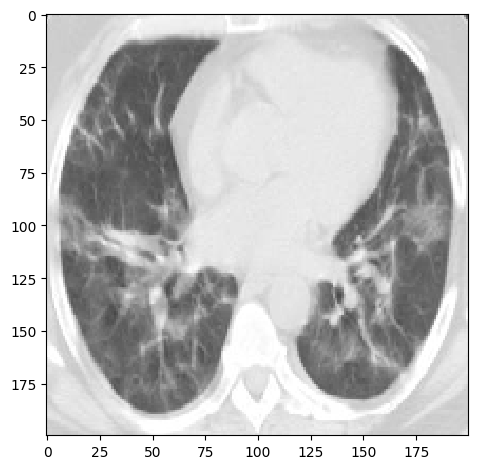

---------------Client 2 sample Image -----------------


/tmp/ipykernel_3253688/3979477622.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(train_features_dataset2_fed[0])
/tmp/ipykernel_3253688/3979477622.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  show()


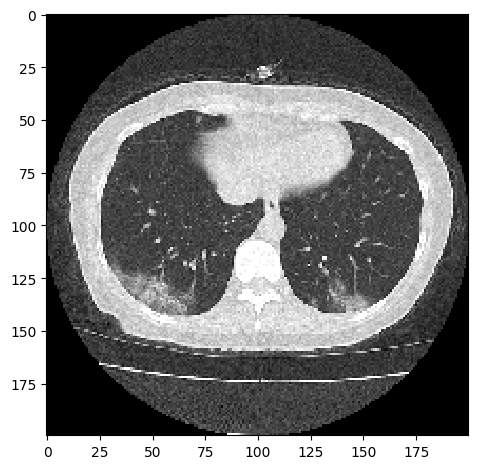

---------------Client 3 sample Image -----------------


/tmp/ipykernel_3253688/3979477622.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(train_features_dataset3_fed[100])
/tmp/ipykernel_3253688/3979477622.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  show()


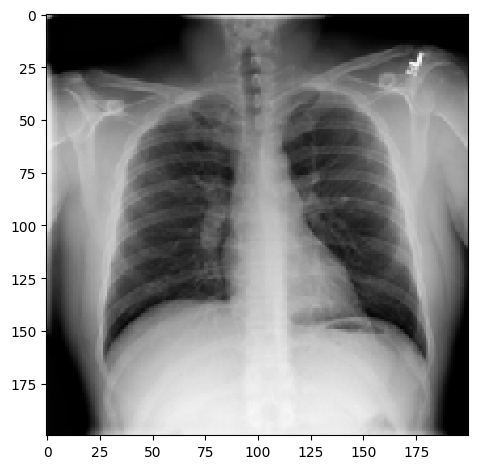

In [390]:
print('---------------Client 1 sample Image -----------------')
imshow(train_features_dataset1_fed[0])
show()
print('---------------Client 2 sample Image -----------------')
imshow(train_features_dataset2_fed[0])
show()
print('---------------Client 3 sample Image -----------------')
imshow(train_features_dataset3_fed[100])
show()

In [391]:
print('--------------------- Testing dataset--------------')
# Assuming client_images and client_labels are numpy arrays or lists of numpy arrays
X_test_combined = np.concatenate((test_features_dataset1_fed, test_features_dataset2_fed,
                                  test_features_dataset3_fed), axis=0)
y_test_combined = np.concatenate((test_labels_dataset1_fed, test_labels_dataset2_fed,
                                  test_labels_dataset3_fed), axis=0)

--------------------- Testing dataset--------------


### **Preparing The Federated Dataset (non_iid Dataset)**

Mean Pixel Value: 131.9899020982143
Variance of Pixel Values: 8683.096213166311
Standard Deviation of Pixel Values: 93.18313266448123


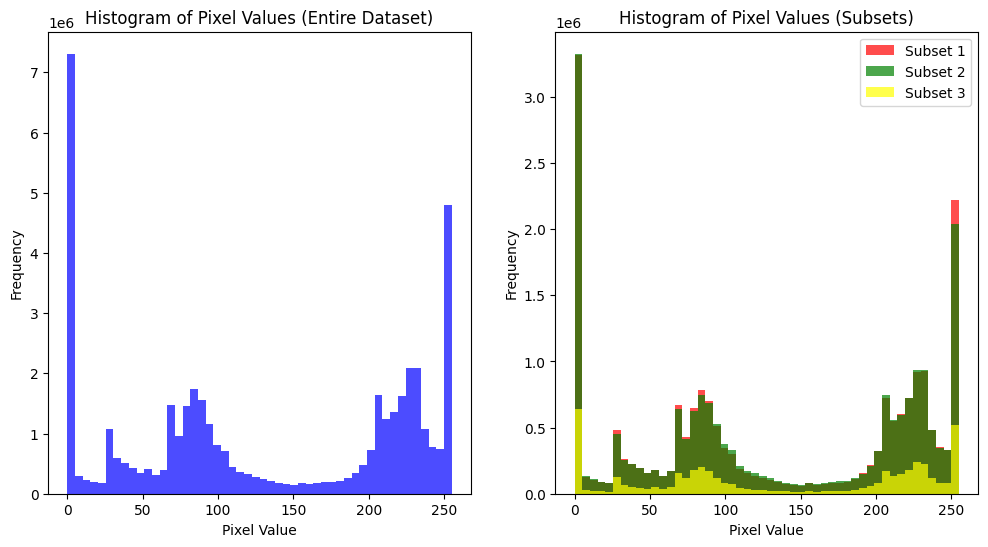

Mean Pixel Value: 120.98203176498878
Variance of Pixel Values: 6610.608979491026
Standard Deviation of Pixel Values: 81.30565158395218


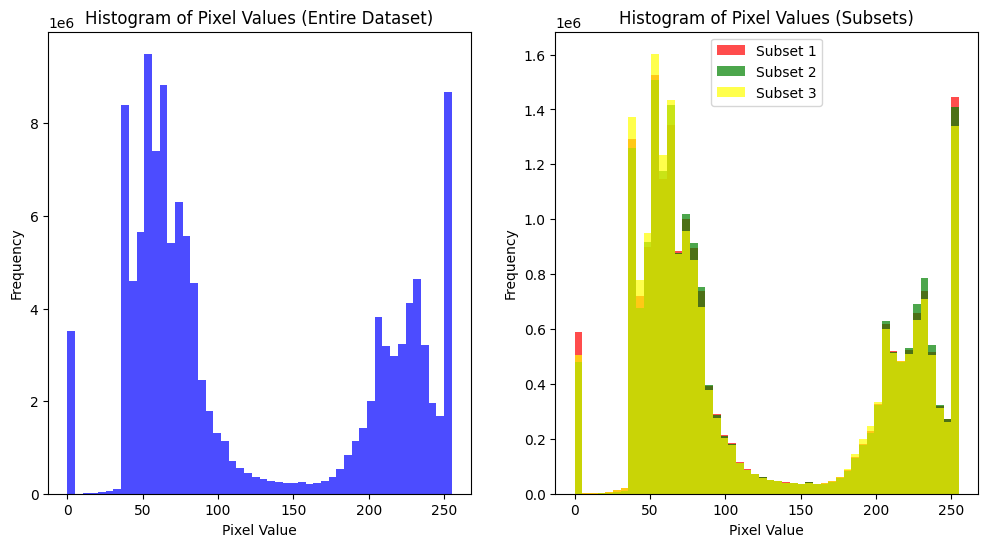

Mean Pixel Value: 131.8335830589985
Variance of Pixel Values: 4271.120682620385
Standard Deviation of Pixel Values: 65.35381153858117


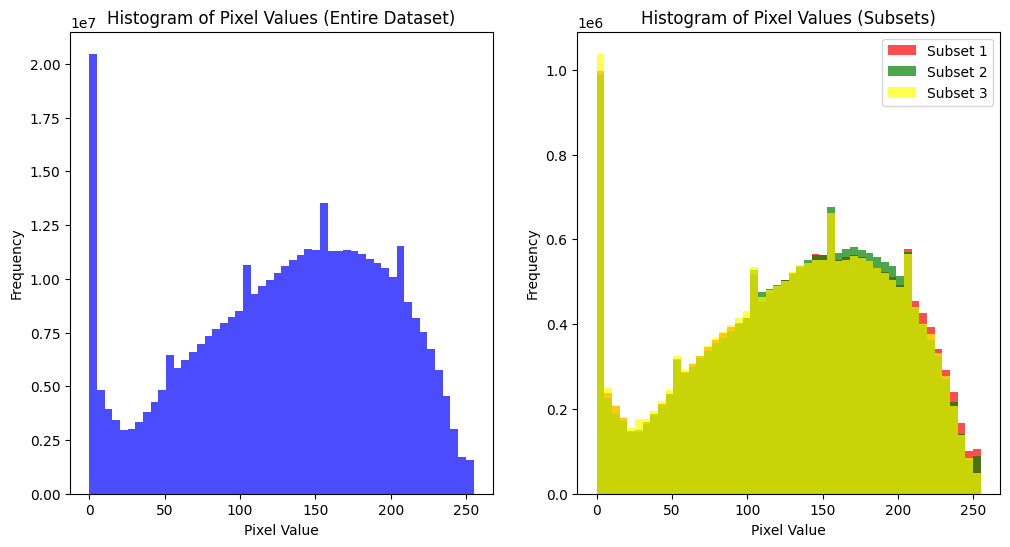

In [392]:
dataset_pixel_stat(train_features_dataset1_fed)
dataset_pixel_stat(train_features_dataset2_fed)
dataset_pixel_stat(train_features_dataset3_fed)

##### **non-iid Federated Dataset (unbalanced)**

In [393]:
client_data = [(train_features_dataset1_fed, train_labels_dataset1_fed),
              (train_features_dataset2_fed, train_labels_dataset2_fed),
              (train_features_dataset3_fed, train_labels_dataset3_fed)]#(train_features_dataset3_fed, train_labels_dataset3_fed)

NUM_CLIENTS = len(client_data)  # Number of clients
BATCH_SIZE = 20

def create_tf_dataset_for_client(client_dataset):
    """Create a tf.data.Dataset object for a client's data."""
    client_images, client_labels = client_dataset
    dataset = tf.data.Dataset.from_tensor_slices((client_images, client_labels))
    return dataset

client_datasets = [create_tf_dataset_for_client(data) for data in client_data]

def preprocess_dataset(dataset, batch_size=BATCH_SIZE , shuffle_buffer_size=10000000):
    """Preprocess the dataset."""
    return dataset.shuffle(shuffle_buffer_size).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
#federated_clients
fed_clients = ['client_'+str(i) for i in range(1,NUM_CLIENTS+1)]

# Federated data preparation
federated_train_data_nonIID_unbalanced = [preprocess_dataset(dataset) for dataset in client_datasets]
print('Fedrated non-iid Unbalanced Dataset Data type: ', type(federated_train_data_nonIID_unbalanced))
print('Length: ', len(federated_train_data_nonIID_unbalanced))

Fedrated non-iid Unbalanced Dataset Data type:  <class 'list'>
Length:  3


#### **non-iid Federated Dataset (balanced)**

In [394]:
client_data = [(train_features_dataset1_fed, train_labels_dataset1_fed),
              (train_features_dataset2_fed[0:1200,:], train_labels_dataset2_fed[0:1200,:]),
              (train_features_dataset3_fed, train_labels_dataset3_fed)]
client_datasets = [create_tf_dataset_for_client(data) for data in client_data]
# Federated data preparation
federated_train_data_nonIID_balanced = [preprocess_dataset(dataset) for dataset in client_datasets]
print('Fedrated non-iid balanced Dataset Data type: ', type(federated_train_data_nonIID_unbalanced))
print('Length: ', len(federated_train_data_nonIID_unbalanced))

Fedrated non-iid balanced Dataset Data type:  <class 'list'>
Length:  3


### **Preparing The Federated Dataset (iid Dataset)**

In [395]:
train_features_dataset1_fed_iid, test_features_dataset1_fed_iid, train_labels_dataset1_fed_iid, test_labels_dataset1_fed_iid = train_test_split(
    input_data_x_2_load[6501:7901,:], output_label_y_2_load[6501:7901,:], test_size=.20, random_state=420)
train_features_dataset2_fed_iid, test_features_dataset2_fed_iid, train_labels_dataset2_fed_iid, test_labels_dataset2_fed_iid = train_test_split(
    input_data_x_2_load[7901:11800,:], output_label_y_2_load[7901:11800,:], test_size=.20, random_state=42000)
train_features_dataset3_fed_iid, test_features_dataset3_fed_iid, train_labels_dataset3_fed_iid, test_labels_dataset3_fed_iid = train_test_split(
    input_data_x_2_load[11800:13139,:], output_label_y_2_load[11800:13139,:], test_size=.20, random_state=402)
print('client 1 federated dataset: ', train_features_dataset1_fed_iid.shape, test_features_dataset1_fed_iid.shape, train_labels_dataset1_fed_iid.shape, test_labels_dataset1_fed_iid.shape)
print('client 2 federated dataset: ', train_features_dataset2_fed_iid.shape, test_features_dataset2_fed_iid.shape, train_labels_dataset2_fed_iid.shape, test_labels_dataset2_fed_iid.shape)
print('client 3 federated dataset: ', train_features_dataset3_fed_iid.shape, test_features_dataset3_fed_iid.shape, train_labels_dataset3_fed_iid.shape, test_labels_dataset3_fed_iid.shape)

client 1 federated dataset:  (1120, 200, 200, 1) (280, 200, 200, 1) (1120, 2) (280, 2)
client 2 federated dataset:  (3119, 200, 200, 1) (780, 200, 200, 1) (3119, 2) (780, 2)
client 3 federated dataset:  (1071, 200, 200, 1) (268, 200, 200, 1) (1071, 2) (268, 2)


---------------Client 1 sample Image -----------------


/tmp/ipykernel_3253688/2712620368.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(train_features_dataset1_fed_iid[100])
/tmp/ipykernel_3253688/2712620368.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  show()


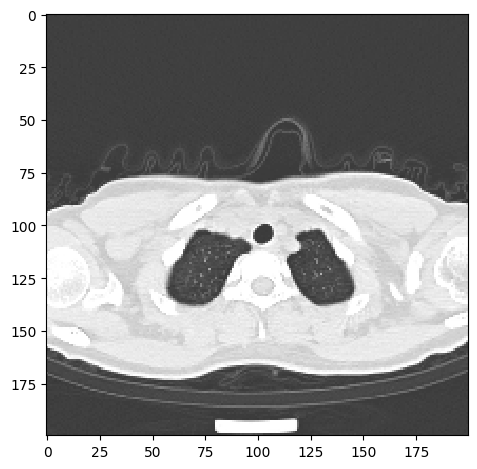

---------------Client 2 sample Image -----------------


/tmp/ipykernel_3253688/2712620368.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(train_features_dataset2_fed_iid[0])
/tmp/ipykernel_3253688/2712620368.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  show()


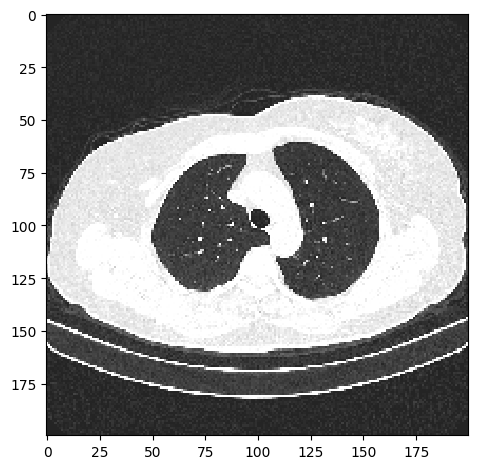

---------------Client 3 sample Image -----------------


/tmp/ipykernel_3253688/2712620368.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(train_features_dataset3_fed_iid[0])
/tmp/ipykernel_3253688/2712620368.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  show()


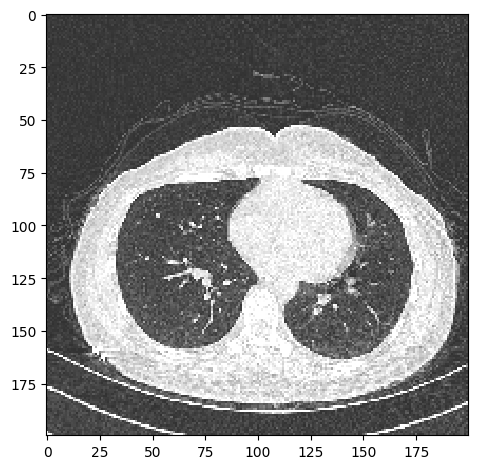

In [396]:
print('---------------Client 1 sample Image -----------------')
imshow(train_features_dataset1_fed_iid[100])
show()
print('---------------Client 2 sample Image -----------------')
imshow(train_features_dataset2_fed_iid[0])
show()
print('---------------Client 3 sample Image -----------------')
imshow(train_features_dataset3_fed_iid[0])
show()

Mean Pixel Value: 121.04263109375
Variance of Pixel Values: 6613.456164442539
Standard Deviation of Pixel Values: 81.32315884446778


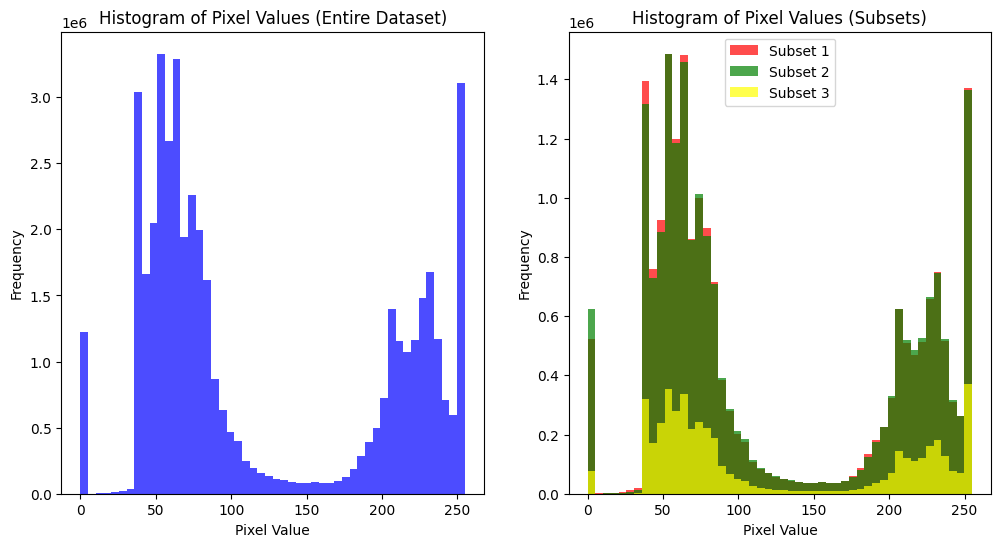

Mean Pixel Value: 121.23144277011863
Variance of Pixel Values: 6609.921206318524
Standard Deviation of Pixel Values: 81.3014219206437


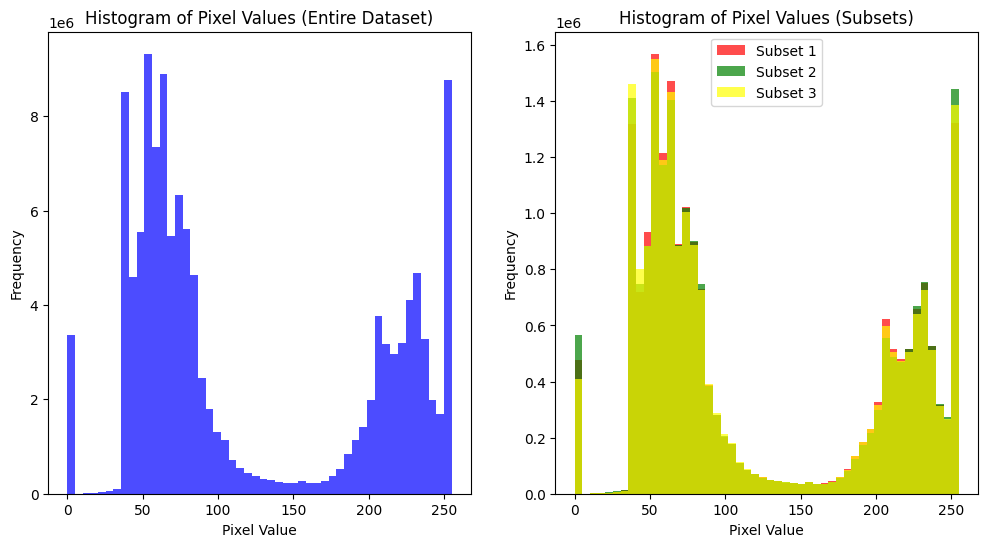

Mean Pixel Value: 121.0545436041083
Variance of Pixel Values: 6598.427664864534
Standard Deviation of Pixel Values: 81.23070641613634


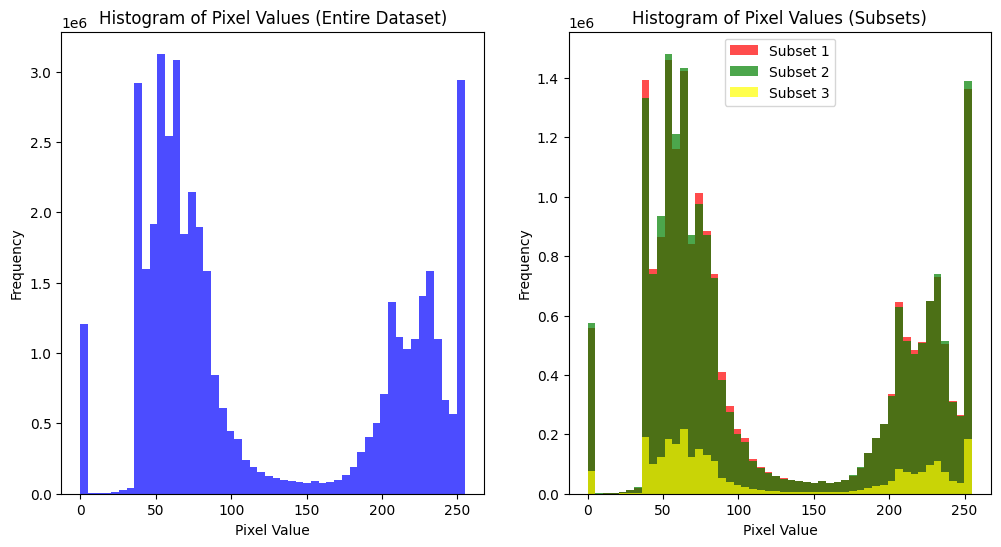

In [397]:
dataset_pixel_stat(train_features_dataset1_fed_iid)
dataset_pixel_stat(train_features_dataset2_fed_iid)
dataset_pixel_stat(train_features_dataset3_fed_iid)

#### **iid Federated Dataset (unbalanced)**

In [398]:
client_data = [(train_features_dataset1_fed_iid, train_labels_dataset1_fed_iid),
              (train_features_dataset2_fed_iid, train_labels_dataset2_fed_iid),
              (train_features_dataset3_fed_iid, train_labels_dataset3_fed_iid)]
client_datasets = [create_tf_dataset_for_client(data) for data in client_data]
# Federated data preparation
federated_train_data_IID_unbalanced = [preprocess_dataset(dataset) for dataset in client_datasets]
print('Fedrated iid unbalanced Dataset Data type: ', type(federated_train_data_IID_unbalanced))
print('Length: ', len(federated_train_data_IID_unbalanced))

Fedrated iid unbalanced Dataset Data type:  <class 'list'>
Length:  3


#### **iid Federated Dataset (balanced)**

In [399]:
client_data = [(train_features_dataset1_fed_iid, train_labels_dataset1_fed_iid),
              (train_features_dataset2_fed_iid[0:1200,:], train_labels_dataset2_fed_iid[0:1200,:]),
              (train_features_dataset3_fed_iid, train_labels_dataset3_fed_iid)]
client_datasets = [create_tf_dataset_for_client(data) for data in client_data]
# Federated data preparation
federated_train_data_IID_balanced = [preprocess_dataset(dataset) for dataset in client_datasets]
print('Fedrated iid balanced Dataset Data type: ', type(federated_train_data_IID_balanced))
print('Length: ', len(federated_train_data_IID_balanced))

Fedrated iid balanced Dataset Data type:  <class 'list'>
Length:  3


## **Federated Learning Training**

In order to use this model in TFF, wrap the Keras model as a [`tff.learning.models.VariableModel`](https://www.tensorflow.org/federated/api_docs/python/tff/learning/Model). This allows one to perform the model's [forward pass](https://www.tensorflow.org/federated/api_docs/python/tff/learning/Model#forward_pass) within TFF, and [extract model outputs](https://www.tensorflow.org/federated/api_docs/python/tff/learning/Model#report_local_unfinalized_metrics). For more details, also see the [image classification](federated_learning_for_image_classification.ipynb) tutorial.

### **Wrapping Teacher Models ass TFF models**

In [400]:
def create_keras_model():#this is student model
    initializer = tf.keras.initializers.GlorotNormal(seed=0)
    return tf.keras.models.Sequential([
      tf.keras.layers.InputLayer(input_shape=(IMAGE_SIZE,IMAGE_SIZE,1)),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
      tf.keras.layers.Flatten(),#### Added this march 6 2024
      tf.keras.layers.Dense(2, kernel_initializer=initializer),
      tf.keras.layers.Softmax(),
    ])

def model_fn(initial_weights=None):
    keras_model = create_keras_model()
    if initial_weights is not None:
        keras_model.set_weights(initial_weights)
    return tff.learning.models.from_keras_model(
      keras_model,
      input_spec=federated_train_data_nonIID_unbalanced[0].element_spec,
      loss=tf.keras.losses.CategoricalCrossentropy(),
      metrics=[tf.keras.metrics.CategoricalAccuracy()])

# # Define data augmentation layers

def teacher_Mod(model, num_hl, hl_list,hl_conv_activation, ol_activation, dropout_val, inputShape,filters_,kernel_size_,stride_poolSize):
    '''
    teacher_Mod(model, num_hl, hl_list,hl_conv_activation, ol_activation, dropout_val, inputShape,filters_,kernel_size_,stride_poolSize):
        model = CNN Model
        num_hl = number of hidden layers
        hl_list = list of hidden layers
        hl_activation = hidden layer activation function
        out_activation = output layer activation function
        dropout_val = Dropout value
        inputShape = shape of input layer
        filters_ = filter size of Conv layer
        kernel_size_ = size of kernel (x,x)
        strides_poolSize = strides and max_pool_szie
    '''
    assert(num_hl == len(hl_list))
    assert(num_hl == len(dropout_val))

    inputs = tf.keras.layers.Input(shape=inputShape)
    image_size_ = 200
    data_augmentation = keras.Sequential(
        [
            tf.keras.layers.Normalization(),
            tf.keras.layers.Resizing(image_size_, image_size_),
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(factor=0.02),
            tf.keras.layers.RandomZoom(
                height_factor=0.2, width_factor=0.2
            ),
        ],
        name="data_augmentation",
    )
    augmented = data_augmentation(inputs)
    #connnnvolultion layer 1 with Map-pooling
    conv_layer_1 = tf.keras.layers.Conv2D(filters = filters_,kernel_size = kernel_size_,
                        strides = stride_poolSize, activation = hl_conv_activation)(augmented)#(inputs)
    conv_layer_1_max_pool = tf.keras.layers.MaxPool2D(strides=stride_poolSize)(conv_layer_1)
    x1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(conv_layer_1_max_pool)

    #connnnvolultion layer 1 with Map-pooling
    conv_layer_2 = tf.keras.layers.Conv2D(filters = filters_,kernel_size = kernel_size_,strides = stride_poolSize, activation = hl_conv_activation)(x1)
    conv_layer_2_max_pool = tf.keras.layers.MaxPool2D(strides=stride_poolSize)(conv_layer_2)
    x2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(conv_layer_2_max_pool)

    flatten_layer = tf.keras.layers.Flatten()(x2)

    dense_layers = tf.keras.layers.Dense(units = hl_list[0], activation = hl_conv_activation)(flatten_layer)
    dense_layers = tf.keras.layers.Dropout(dropout_val[0])(dense_layers)
    #dense_layers = tf.keras.layers.LayerNormalization()(dense_layers)           # Batch normalization layer

    dense_layers = tf.keras.layers.Dense(units = hl_list[1], activation = hl_conv_activation)(dense_layers)
    dense_layers = tf.keras.layers.Dropout(dropout_val[1])(dense_layers)
    #dense_layers = tf.keras.layers.LayerNormalization()(dense_layers)

    dense_layers = tf.keras.layers.Dense(units = hl_list[2], activation = hl_conv_activation)(dense_layers)
    dense_layers = tf.keras.layers.Dropout(dropout_val[2])(dense_layers)
    #dense_layers = tf.keras.layers.LayerNormalization()(dense_layers)

    dense_layers = tf.keras.layers.Dense(units = hl_list[3], activation = hl_conv_activation)(dense_layers)
    dense_layers = tf.keras.layers.Dropout(dropout_val[3])(dense_layers)
    #dense_layers = tf.keras.layers.LayerNormalization()(dense_layers)

    logits = tf.keras.layers.Dense(units = 2, activation = ol_activation)(dense_layers)

    # Create the Keras model.
    model = tf.keras.Model(inputs=inputs,outputs=logits)
    #model = compile_model(model, 'categorical_crossentropy',0.0010621475226496656,['accuracy'])
    return model

#CNN Teacher Model wrapping as TFF model
def COVIDCNN_model_fn_teacher(initial_weights=None):
    keras_model  = tf.keras.models.Sequential()
    keras_model  = teacher_Mod(keras_model, 4, [362, 184, 78, 12],'relu','softmax',[0.00,0.35,0.0,0.00],(IMAGE_SIZE,IMAGE_SIZE,1),116,8,2)
    if initial_weights is not None:
        keras_model.set_weights(initial_weights)
    return tff.learning.models.from_keras_model(
      keras_model,
      input_spec=federated_train_data_nonIID_unbalanced[0].element_spec,
      loss=tf.keras.losses.CategoricalCrossentropy(),
      metrics=[tf.keras.metrics.CategoricalAccuracy()])

def build_DEEPCOVID_model(OPTIMIZER, LOSS, METRICS):
    input_tensor = Input(shape=input_shape)
    input_rgb = Lambda(lambda x: K.repeat_elements(x, 3, axis=-1))(input_tensor)
    model = None
    inputs = layers.Input(shape=input_shape)
    x = inputs#img_augmentation(inputs)
    baseModel = keras.applications.NASNetLarge(
    #input_shape=input_shape,
    include_top=False,
    weights="imagenet",
    input_tensor=input_rgb,
    pooling='avg',
    classifier_activation="softmax",
)
    #baseModel = NETWORK(include_top=False, input_tensor=x, weights="imagenet", pooling ='avg')

    baseModel.trainable = False

    #x = BatchNormalization(axis = -1, name="Batch-Normalization-1")(baseModel.output)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6, name="Layer-Normalization-1")(baseModel.output)
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4))(x)
    x = BatchNormalization(axis = -1, name="Batch-Normalization-2")(x)
    x = Dropout(.2, name="Dropout-1")(x)

    x = Dense(256, activation='relu')(x)
    x = BatchNormalization(axis = -1, name="Batch-Normalization-3")(x)

    outputs = Dense(NUM_CLASSES, activation="softmax", name="Classifier")(x)
    model = tf.keras.Model(inputs=baseModel.input, outputs=outputs, name="Deep-COVID")

    #model.compile(optimizer = OPTIMIZER, loss = LOSS, metrics = METRICS)

    return model

#DEEO-COVID Teacher Model wrapping as TFF model
def DEEPCOVID_model_fn_teacher(initial_weights=None):
    keras_model = build_DEEPCOVID_model(OPTIMIZER, LOSS, METRICS)
    if initial_weights is not None:
        keras_model.set_weights(initial_weights)
    return tff.learning.models.from_keras_model(
      keras_model,
      input_spec=federated_train_data_nonIID_unbalanced[0].element_spec,
      loss=tf.keras.losses.CategoricalCrossentropy(),
      metrics=[tf.keras.metrics.CategoricalAccuracy()])

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Activation, GlobalAveragePooling2D, Input
from tensorflow.keras.layers import Lambda
# input_tensor = Input(shape=(IMAGE_SIZE,IMAGE_SIZE,1))
# input_rgb = Lambda(lambda x: K.repeat_elements(x, 3, axis=-1))(input_tensor)


def CNN_Mod_VGG16(num_hl, hl_list, hl_conv_activation, ol_activation, dropout_val, inputShape, filters_, kernel_size_, stride_poolSize):
    '''
    CNN_Mod(num_hl, hl_list, hl_conv_activation, ol_activation, dropout_val, inputShape, filters_, kernel_size_, stride_poolSize):
        num_hl = number of hidden layers
        hl_list = list of hidden layer units
        hl_activation = hidden layer activation function
        out_activation = output layer activation function
        dropout_val = Dropout value
        inputShape = shape of input layer
        filters_ = filter size of Conv layer
        kernel_size_ = size of kernel (x,x)
        strides_poolSize = strides and max_pool_szie
    '''
    assert num_hl == len(hl_list)
    assert num_hl == len(dropout_val)
    input_tensor = Input(shape=(IMAGE_SIZE,IMAGE_SIZE,1))
    input_rgb = Lambda(lambda x: K.repeat_elements(x, 3, axis=-1))(input_tensor)
    inputs = tf.keras.layers.Input(shape=inputShape)
    # Augment data.
    image_size_ = 200
    data_augmentation = keras.Sequential(
        [
            tf.keras.layers.Normalization(),
            tf.keras.layers.Resizing(image_size_, image_size_),
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(factor=0.02),
            tf.keras.layers.RandomZoom(
                height_factor=0.2, width_factor=0.2
            ),
        ],
        name="data_augmentation",
    )
    augmented = data_augmentation(inputs)

    # Load EfficientNet as base model
    base_model = VGG16(include_top=False, input_tensor=input_rgb, weights='imagenet')

    # Freeze the base model
    base_model.trainable = False

    # Add custom head
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    for i in range(num_hl):
        x = tf.keras.layers.Dense(units=hl_list[i], activation=hl_conv_activation)(x)
        x = tf.keras.layers.Dropout(dropout_val[i])(x)

    # Output layer
    logits = tf.keras.layers.Dense(units=2, activation=ol_activation)(x)

    # Create the Keras model
    model = tf.keras.Model(inputs=base_model.input, outputs=logits)

    # Compile the model
    #model = compile_model(model, 'categorical_crossentropy', 0.001, ['accuracy'])

    return model

#CNN_Mod_VGG16 Teacher Model wrapping as TFF model
def CNN_Mod_VGG16_fn_teacher(initial_weights=None):
    keras_model = CNN_Mod_VGG16(4, [2756, 1776, 620, 152],'relu','softmax',[0.65,0.00,0.00,0.65],(IMAGE_SIZE,IMAGE_SIZE,1),214,5,3)
    if initial_weights is not None:
        keras_model.set_weights(initial_weights)
    return tff.learning.models.from_keras_model(
      keras_model,
      input_spec=federated_train_data_nonIID_unbalanced[0].element_spec,
      loss=tf.keras.losses.CategoricalCrossentropy(),
      metrics=[tf.keras.metrics.CategoricalAccuracy()])

While the above used `tf.keras` to create a `tff.learning.models.VariableModel`, TFF supports much more general models. These models have the following relevant attributes capturing the model weights:

*   `trainable_variables`: An iterable of the tensors corresponding to trainable layers.
*   `non_trainable_variables`: An iterable of the tensors corresponding to non-trainable layers.

In this tutorial, only the `trainable_variables` will be used. (as the model only has those!).

### **Building your own Federated Learning algorithm**

While the `tff.learning` API allows one to create many variants of Federated Averaging, there are other federated algorithms that do not fit neatly into this framework. For example, you may want to add regularization, clipping, or more complicated algorithms such as [federated GAN training](https://github.com/tensorflow/federated/tree/main/tensorflow_federated/python/research/gans). You may also be instead be interested in [federated analytics](https://ai.googleblog.com/2020/05/federated-analytics-collaborative-data.html).

For these more advanced algorithms, you'll have to write our own custom algorithm using TFF. In many cases, federated algorithms have 4 main components:

1. A server-to-client broadcast step.
2. A local client update step.
3. A client-to-server upload step.
4. A server update step.

In TFF, we generally represent federated algorithms as a tff.templates.IterativeProcess (which we refer to as just an IterativeProcess throughout). This is a class that contains initialize and next functions. Here, initialize is used to initialize the server, and next will perform one communication round of the federated algorithm.

We will introduce different components to build the federated averaging (FedAvg) algorithm, which will use an optimizer in the client update step, and another optimizer in the server update step. The core logics of client and server updates can be expressed as pure TF blocks.

#### **TF blocks: client and server update**
On each client, a local client_optimizer is initialized and used to update the client model weights. On the server, server_optimizer will use the state from the previous round, and update the state for the next round.

##### **Federated Learning Multi-Teacher Knowledge Distillation (FL-MTKD client update)**

In [401]:
class Distiller_multT_weightedTeachers(tf.keras.Model):#no teacher weights
    def __init__(self, optimizer, alpha, temperature, student_loss_fn, distillation_loss_fn, student,
                 teachers):
        super().__init__()
        self.student = student
        self.teachers = teachers  # This remains a list of teacher models
        self.optimizer = optimizer
        self.optimizer_t_weights = optimizer#tf.keras.optimizers.Adam(learning_rate=0.001)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.temperature = temperature
        self.alpha = alpha
        self.epoch_loss_avg = tf.keras.metrics.Mean()
#         self.t_weights = tf.Variable(tf.ones(3), trainable=True, dtype=tf.float32)

    def normalize_logits(self,logits):
        min_val = tf.reduce_min(logits, axis=-1, keepdims=True)
        max_val = tf.reduce_max(logits, axis=-1, keepdims=True)
        normalized_logits = (logits - min_val) / (max_val - min_val + 1e-8)
        return normalized_logits
    @tf.function
    def client_update(self, dataset, server_weights, teacher_weights, t_model_select, mu=0.1):
        # Initialize the client model with the current server weights.
        client_weights = self.student.trainable_variables

        # Assign the server weights to the client model.
        tf.nest.map_structure(lambda x, y: x.assign(y), client_weights, server_weights)

        num_pretrain_epochs = 1
        num_total_epochs = 2
        batch_size = 32
        num_steps_per_epoch = 10
        alpha = 0.7
        beta = 0.3
        temperature = 3.0

        # Initialize the client optimizer.
        trainable_tensor_specs = tf.nest.map_structure(
            lambda v: tf.TensorSpec(v.shape, v.dtype), client_weights)
        optimizer_state = self.optimizer.initialize(trainable_tensor_specs)

        # Pre-training phase
        for epoch in range(num_pretrain_epochs):
            print(f'Pre-train Epoch {epoch+1}/{num_pretrain_epochs}')
            for batch in iter(dataset):
                x_batch_train, y_batch_train = batch
                x_reshaped = tf.reshape(x_batch_train, (-1, IMAGE_SIZE, IMAGE_SIZE, 1))

                with tf.GradientTape() as tape:
                    student_pred = self.student.forward_pass((x_reshaped, y_batch_train), training=True).predictions
                    teacher_preds = [teacher.forward_pass((x_reshaped, y_batch_train), training=False).predictions for teacher in self.teachers]

                    distillation_losses = [self.distillation_loss_fn(
                        tf.nn.softmax(teacher_pred / self.temperature, axis=1),
                        tf.nn.softmax(student_pred / self.temperature, axis=1)
                    ) * (self.temperature ** 2) for teacher_pred in teacher_preds]

                    avg_distillation_loss = tf.reduce_sum([loss*teacher_weights[i] for i,loss in enumerate(distillation_losses)]) #tf.reduce_mean(distillation_losses)
                    loss = avg_distillation_loss

                gradients = tape.gradient(loss, client_weights)
                optimizer_state, updated_weights = self.optimizer.next(optimizer_state, client_weights, gradients)
                tf.nest.map_structure(lambda a, b: a.assign(b), client_weights, updated_weights)

                print(f'Pre-train Epoch {epoch + 1}, Loss: {loss}')

        # Transition to combined loss
        for epoch in range(num_pretrain_epochs, num_total_epochs):
            print(f'Train Epoch {epoch+1}/{num_total_epochs}')
            for batch in iter(dataset):
                x_batch_train, y_batch_train = batch
                x_reshaped = tf.reshape(x_batch_train, (-1, IMAGE_SIZE, IMAGE_SIZE, 1))

                with tf.GradientTape() as tape:
                    student_pred = self.student.forward_pass((x_reshaped, y_batch_train), training=True).predictions
                    teacher_preds = [teacher.forward_pass((x_reshaped, y_batch_train), training=False).predictions for teacher in self.teachers]

                    distillation_losses = [self.distillation_loss_fn(
                        tf.nn.softmax(teacher_pred / self.temperature, axis=1),
                        tf.nn.softmax(student_pred / self.temperature, axis=1)
                    ) * (self.temperature ** 2) for teacher_pred in teacher_preds]

                    avg_distillation_loss = tf.reduce_sum([loss*teacher_weights[i] for i,loss in enumerate(distillation_losses)]) #tf.reduce_mean(distillation_losses)
                    ce_loss_val = self.student_loss_fn(y_batch_train, student_pred)
                    combined_loss = self.alpha * ce_loss_val + (1-self.alpha) * avg_distillation_loss
                    loss = combined_loss

                gradients = tape.gradient(loss, client_weights)
                optimizer_state, updated_weights = self.optimizer.next(optimizer_state, client_weights, gradients)
                tf.nest.map_structure(lambda a, b: a.assign(b), client_weights, updated_weights)

                print(f'Epoch {epoch + 1}, Loss: {loss}')

        return tf.nest.map_structure(tf.subtract, client_weights, server_weights)


##### **Server Update**

The server update for FedAvg is simpler than the client update. This tutorial will implement "vanilla" federated averaging, in which the server model weights are replaced by the average of the client model weights. Again, this only uses the trainable weights.

In [402]:
import attrs
from typing import Any#         with tf.GradientTape() as tape:

import functools
@attrs.define(eq=False, frozen=True)
class ServerState(object):
    trainable_weights: Any
    optimizer_state: Any

@tf.function
def server_update(server_state, mean_model_delta, server_optimizer):
    """Updates the server model weights."""
    # Use aggregated negative model delta as pseudo gradient.
    negative_weights_delta = tf.nest.map_structure(
      lambda w: -1.0 * w, mean_model_delta)
    new_optimizer_state, updated_weights = server_optimizer.next(
      server_state.optimizer_state, server_state.trainable_weights,
      negative_weights_delta)
    return tff.structure.update_struct(
      server_state,
      trainable_weights=updated_weights,
      optimizer_state=new_optimizer_state)

#### TFF blocks: tff.tf_computation and tff.federated_computation
We now use TFF for orchestration and build the iterative process for FedAvg. We have to wrap the TF blocks defined above with tff.tf_computation, and use TFF methods tff.federated_broadcast, tff.federated_map, tff.federated_mean in a tff.federated_computation function. It is easy to use the tff.learning.optimizers.Optimizer APIs with initialize and next functions when defining a custom iterative process.

In [403]:
#1. Server and client optimizer to be used.
server_optimizer = tff.learning.optimizers.build_sgdm(
    learning_rate=0.1, momentum=0.9)#lr = 0.01 last run was 0.01 and acc was 74.12 # lr =0.05 momentum = 0.5
client_optimizer = tff.learning.optimizers.build_adam(learning_rate = 0.0001, beta_1 = 0.9,beta_2 = 0.99,
    epsilon = 1e-07
)

In [404]:
# 2. Functions return initial state on server.
@tff.tensorflow.computation
def server_init():
    model = model_fn()
    trainable_tensor_specs = tf.nest.map_structure(
        lambda v: tf.TensorSpec(v.shape, v.dtype), model.trainable_variables)
    optimizer_state = server_optimizer.initialize(trainable_tensor_specs)
    return ServerState(
      trainable_weights=model.trainable_variables,
      optimizer_state=optimizer_state)
@tff.federated_computation
def server_init_tff():
    return tff.federated_value(server_init(), tff.SERVER)

In [405]:
# 3. One round of computation and communication.
server_state_type = server_init.type_signature.result
print('server_state_type:\n',
      server_state_type.formatted_representation())
trainable_weights_type = server_state_type.trainable_weights
print('trainable_weights_type:\n',
      trainable_weights_type.formatted_representation())

server_state_type:
 <
  trainable_weights=<
    float32[3,3,1,32],
    float32[32],
    float32[313632,2],
    float32[2]
  >,
  optimizer_state=<
    learning_rate=float32,
    momentum=float32,
    accumulator=<
      float32[3,3,1,32],
      float32[32],
      float32[313632,2],
      float32[2]
    >
  >
>
trainable_weights_type:
 <
  float32[3,3,1,32],
  float32[32],
  float32[313632,2],
  float32[2]
>


In [406]:
# 3-1. Wrap server and client TF blocks with `tff.tf_computation`.
@tff.tensorflow.computation(server_state_type, trainable_weights_type)
def server_update_fn(server_state, model_delta):
    return server_update(server_state, model_delta, server_optimizer)

In [407]:
whimsy_model = model_fn()
tf_dataset_type = tff.SequenceType(tff.types.tensorflow_to_type(whimsy_model.input_spec))
print('tf_dataset_type:\n',
      tf_dataset_type.formatted_representation())

# @tff.tf_computation(tf_dataset_type, trainable_weights_type)
# def client_update_fn(dataset, server_weights):
#     model = model_fn()
#     return client_update(model, dataset, server_weights, client_optimizer)

tf_dataset_type:
 <
  uint8[?,200,200,1],
  bool[?,2]
>*


In [408]:
t_weights = np.array([[1.7,0.85,0.85],[0.6,1.2,0.6], [0.80,0.80,1.6]], dtype='float32')
teacher_weights_type = tff.TensorType(dtype=t_weights.dtype, shape=[3])
print(teacher_weights_type)

float32[3]


In [409]:
t_model_select = np.array([1,1,1], dtype='float32')
t_model_select_type = tff.TensorType(dtype=np.float32,shape=[3])
print(t_model_select_type)

float32[3]


In [410]:
@tff.tensorflow.computation(tf_dataset_type, trainable_weights_type,teacher_weights_type,t_model_select_type)
def client_update_fn(tf_dataset, server_weights,teacher_weights,t_model_select):

    # Instantiate the student model using model_fn
    student_model = model_fn()

    # Instantiate the teacher model using model_fn_teacher (CNN)
    model_teacher = tf.keras.models.load_model('teacher_CNN_model.h5')#load_model("teacher_CNN_model.h5")
    model_teacher_weight = model_teacher.get_weights()
    CNNModel_teacher = COVIDCNN_model_fn_teacher(model_teacher_weight)#model_fn_teacher()

    # Instantiate the teacher model using DEEPCOVID_model_fn_teacher
    model_teacher = tf.keras.models.load_model('Deep_COVID_teacher_model.h5', compile=False)
    # model_teacher_weight = model_teacher.get_weights()
    # DEEPCOVIDModel_teacher = DEEPCOVID_model_fn_teacher(model_teacher_weight)
    DEEPCOVIDModel_teacher = tff.learning.models.from_keras_model(
        model_teacher,
        input_spec=federated_train_data_nonIID_unbalanced[0].element_spec,
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=[tf.keras.metrics.CategoricalAccuracy()])

    # Instantiate the teacher model using DCD_model_fn_teacher
    model_teacher = tf.keras.models.load_model('CNN_Mod_VGG16_teacher_model.h5')
    model_teacher_weight = model_teacher.get_weights()
    CNN_Mod_VGG16_teacher = CNN_Mod_VGG16_fn_teacher(model_teacher_weight)


    # Instantiate the Distiller with the student and teacher models
    optimizer = client_optimizer

    student_loss_fn=tf.keras.losses.CategoricalCrossentropy(from_logits=True)
    distillation_loss_fn=tf.keras.losses.KLDivergence()

    #initial alpha = 0.5 and temperature = 3, was 10
    distiller = Distiller_multT_weightedTeachers(optimizer,0.6,10,student_loss_fn,distillation_loss_fn,
                         student=student_model,
                        teachers=[CNNModel_teacher,DEEPCOVIDModel_teacher,CNN_Mod_VGG16_teacher])#,CNN_Mod_VGG16_teacher teach_weights = weights_


    # Perform training on the client's dataset using the Distiller
    updated_student_weights = distiller.client_update(tf_dataset, server_weights,teacher_weights,t_model_select)#we don't need tf_clientId here

    return updated_student_weights

2026-01-28 13:21:35.911128: W tensorflow/c/c_api.cc:305] Operation '{name:'dense_1_1/kernel/Assign' id:687 op device:{requested: '', assigned: ''} def:{{{node dense_1_1/kernel/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](dense_1_1/kernel, dense_1_1/kernel/Initializer/stateless_truncated_normal)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-01-28 13:21:37.308037: W tensorflow/c/c_api.cc:305] Operation '{name:'count_2/Assign' id:901 op device:{requested: '', assigned: ''} def:{{{node count_2/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](count_2, count_2/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in t

Pre-train Epoch 1/1
Pre-train Epoch 1, Loss: Tensor("Sum:0", shape=(), dtype=float32)
Train Epoch 2/2
Epoch 2, Loss: Tensor("add:0", shape=(), dtype=float32)


In [411]:
# 3-2. Orchestration with `tff.federated_computation`.
federated_server_type = tff.FederatedType(server_state_type, tff.SERVER)
federated_dataset_type = tff.FederatedType(tf_dataset_type, tff.CLIENTS)
federated_teacher_weights_type = tff.FederatedType(teacher_weights_type, tff.CLIENTS)
#federated_client_weights_type = tff.FederatedType(teacher_weights_type, tff.CLIENTS)
federated_t_model_select_type = tff.FederatedType(t_model_select_type, tff.CLIENTS)
@tff.federated_computation(federated_server_type, federated_dataset_type,federated_teacher_weights_type,federated_t_model_select_type)
def run_one_round(server_state, federated_dataset,federated_teacher_weights,federated_t_model_select):
    # Server-to-client broadcast.
    server_weights_at_client = tff.federated_broadcast(
      server_state.trainable_weights)
    # Local client update.
    model_deltas = tff.federated_map(
      client_update_fn, (federated_dataset, server_weights_at_client,federated_teacher_weights,federated_t_model_select))
    # Client-to-server upload and aggregation.
    mean_model_delta = tff.federated_mean(model_deltas)
    # Server update.
    server_state = tff.federated_map(
      server_update_fn, (server_state, mean_model_delta))
    return server_state

In [412]:
# 4. Build the iterative process for FedAvg.
FL_MTKD = tff.templates.IterativeProcess(
    initialize_fn=server_init_tff, next_fn=run_one_round)
print('type signature of `initialize`:\n',
      FL_MTKD.initialize.type_signature.formatted_representation())
print('type signature of `next`:\n',
      FL_MTKD.next.type_signature.formatted_representation())

type signature of `initialize`:
 ( -> <
  trainable_weights=<
    float32[3,3,1,32],
    float32[32],
    float32[313632,2],
    float32[2]
  >,
  optimizer_state=<
    learning_rate=float32,
    momentum=float32,
    accumulator=<
      float32[3,3,1,32],
      float32[32],
      float32[313632,2],
      float32[2]
    >
  >
>@SERVER)
type signature of `next`:
 (<
  server_state=<
    trainable_weights=<
      float32[3,3,1,32],
      float32[32],
      float32[313632,2],
      float32[2]
    >,
    optimizer_state=<
      learning_rate=float32,
      momentum=float32,
      accumulator=<
        float32[3,3,1,32],
        float32[32],
        float32[313632,2],
        float32[2]
      >
    >
  >@SERVER,
  federated_dataset={<
    uint8[?,200,200,1],
    bool[?,2]
  >*}@CLIENTS,
  federated_teacher_weights={float32[3]}@CLIENTS,
  federated_t_model_select={float32[3]}@CLIENTS
> -> <
  trainable_weights=<
    float32[3,3,1,32],
    float32[32],
    float32[313632,2],
    float32[2]
  

### Evaluating the algorithm

https://www.tensorflow.org/federated/tutorials/custom_federated_algorithm_with_tff_optimizers#evaluating_the_algorithm

In [413]:
# def map_function(input_data, target_data):
#     # Apply any necessary transformations to input_data and target_data here
#     # For example, you can cast the target_data to a different dtype if needed
#     target_data = tf.cast(target_data, tf.float32)
#     return input_data, target_data
def map_function(input_data, target_data):                                                                                                                                                                                                                                   
      # Normalize pixel values from [0,255] to [0,1]                                                                                                                                                                                                                           
      input_data = tf.cast(input_data, tf.float32) / 255.0                                                                                                                                                                                                                     
      target_data = tf.cast(target_data, tf.float32)                                                                                                                                                                                                                           
      return input_data, target_data

test_data = [(X_test_combined,y_test_combined )]
test_datasets = [create_tf_dataset_for_client(data) for data in test_data]
combined_test_data = [preprocess_dataset(dataset) for dataset in test_datasets]
combined_test_data = combined_test_data[0].map(map_function)
print(combined_test_data)

<_MapDataset element_spec=(TensorSpec(shape=(None, 200, 200, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>


In [414]:
def evaluate(server_state, dataset):
    keras_model = create_keras_model()
    keras_model.compile(
      loss=tf.keras.losses.CategoricalCrossentropy(),
      metrics=[tf.keras.metrics.CategoricalAccuracy()]
    )
    keras_model.set_weights(server_state.trainable_weights)
    keras_model.evaluate(dataset,verbose=1)
    return keras_model

server_state = FL_MTKD.initialize()
student_inital_model = evaluate(server_state, combined_test_data)
print('loss: ',student_inital_model.get_metrics_result()['loss'].numpy())
print('Accuracy: ',student_inital_model.get_metrics_result()['categorical_accuracy'].numpy())

180/180 [==============================] - 3s 13ms/step - loss: 0.7094 - categorical_accuracy: 0.3490
loss:  0.7093538
Accuracy:  0.34896705


In [415]:
from sklearn import metrics
import numpy as np

# Define a dummy module-like class to handle the 'meu' alias
class ModelEvaluationUtils:
    @staticmethod
    def get_metrics(true_labels, predicted_labels):
        print('Accuracy:', np.round(metrics.accuracy_score(true_labels, predicted_labels), 4))
        print('Precision:', np.round(metrics.precision_score(true_labels, predicted_labels, average='weighted', zero_division=0), 4))
        print('Recall:', np.round(metrics.recall_score(true_labels, predicted_labels, average='weighted', zero_division=0), 4))
        print('F1 Score:', np.round(metrics.f1_score(true_labels, predicted_labels, average='weighted', zero_division=0), 4))

# Create the alias 'meu' so your existing code works
meu = ModelEvaluationUtils()

9/9 [==============================] - 0s 20ms/step


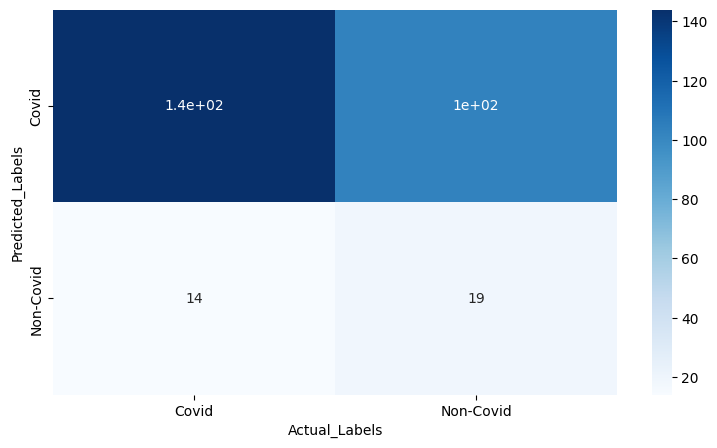

test accuracy = 58.214285714285715%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.5821
Precision: 0.5798
Recall: 0.5821
F1 Score: 0.5081
25/25 [==============================] - 1s 19ms/step


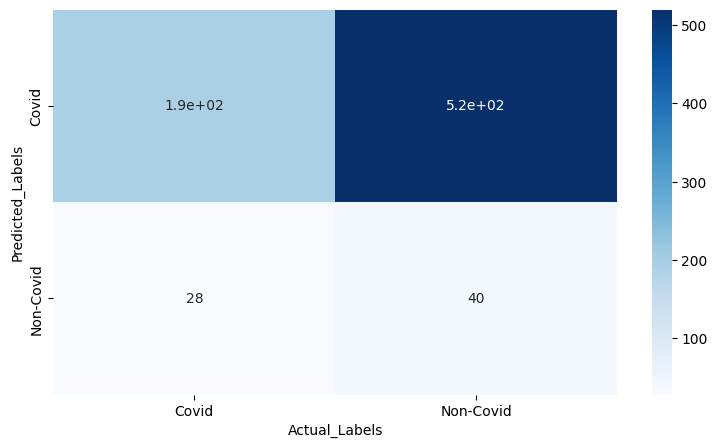

test accuracy = 29.743589743589745%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.2974
Precision: 0.4984
Recall: 0.2974
F1 Score: 0.2077
79/79 [==============================] - 1s 18ms/step


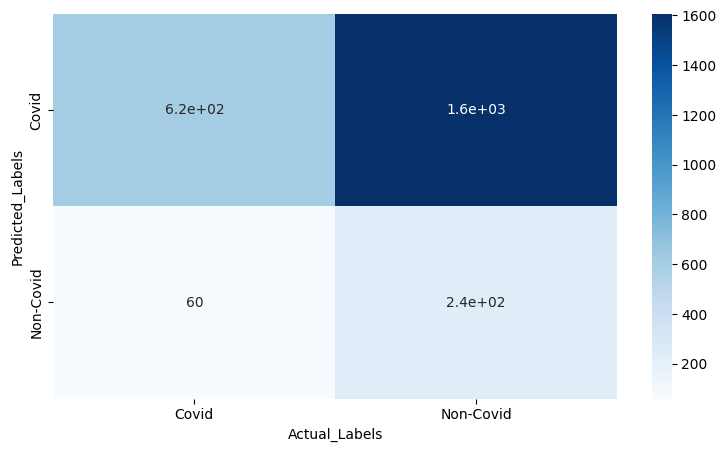

test accuracy = 33.901665344964314%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.339
Precision: 0.66
Recall: 0.339
F1 Score: 0.2774


In [416]:
getModelEvaluation(student_inital_model,test_features_dataset1_fed,test_labels_dataset1_fed)
getModelEvaluation(student_inital_model,test_features_dataset2_fed,test_labels_dataset2_fed)
getModelEvaluation(student_inital_model,test_features_dataset3_fed,test_labels_dataset3_fed)

## FL-MTKD Experiments

<!-- - federated_train_data_nonIID_unbalanced [1120, 3119, 1071]
- federated_train_data_nonIID_balanced [1120, 3119, 1071]
- federated_train_data_IID_unbalanced [1120, 1200, 1071]
- federated_train_data_IID_balanced [1120, 1200, 1071] -->

## Scalable Model Compression via Entropy-Penalized Reparameterization

This section implements the proposed solution from the project document:
- **Entropy-penalized reparameterization** for compressing the student model
- **Client-side compression**: Compress model before sending to server
- **Server-side compression**: Compress global model before redistributing

Reference: Oktay, D., Ballé, J., Singh, S., & Shrivastava, A. (2020). "Scalable Model Compression by Entropy-Penalized Reparameterization" (ICLR 2020)

### 1. Entropy Model for Rate Estimation

The entropy model estimates the probability distribution of latent parameters θ. This allows us to:
1. Estimate the bit-rate (entropy) of the compressed representation
2. Add an entropy penalty to the loss function to encourage compressible weights
3. Use arithmetic coding for actual compression

The key idea: `H(θ) = -E[log p(θ)]` where p(θ) is modeled by a factorized prior.

In [417]:
"""
Entropy-Penalized Reparameterization for Scalable Model Compression
Based on: Oktay et al. (2020) - "Scalable Model Compression by Entropy-Penalized Reparameterization"
"""

import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np

class EntropyModel(tf.keras.layers.Layer):
    """
    Factorized entropy model for estimating the bit-rate of latent parameters.
    
    This model learns a non-parametric, fully factorized density model over the 
    latent parameters θ. The entropy H(θ) = -E[log p(θ)] serves as a differentiable
    proxy for the actual bit-rate after quantization and entropy coding.
    
    Key components:
    - Learnable CDF parameters for each latent dimension
    - Uniform noise addition during training (straight-through estimator for quantization)
    - Log-likelihood computation for entropy penalty
    """
    
    def __init__(self, num_filters=3, init_scale=10.0, **kwargs):
        """
        Args:
            num_filters: Number of filters in the density model (controls expressiveness)
            init_scale: Initial scale for the density model parameters
        """
        super(EntropyModel, self).__init__(**kwargs)
        self.num_filters = num_filters
        self.init_scale = init_scale
        
    def build(self, input_shape):
        """Build learnable parameters for the factorized entropy model."""
        # Number of channels/dimensions to model
        channels = int(input_shape[-1]) if len(input_shape) > 1 else 1
        
        # Initialize density model parameters
        # These define a flexible, learnable CDF for each channel
        filters = (1,) + (self.num_filters,) * 3 + (1,)
        scale = self.init_scale ** (1.0 / (len(filters) - 1))
        
        self._matrices = []
        self._biases = []
        self._factors = []
        
        for i in range(len(filters) - 1):
            init = np.log(np.expm1(1.0 / scale / filters[i + 1]))
            matrix = self.add_weight(
                name=f"matrix_{i}",
                shape=(channels, filters[i + 1], filters[i]),
                initializer=tf.initializers.Constant(init),
                trainable=True
            )
            self._matrices.append(matrix)
            
            bias = self.add_weight(
                name=f"bias_{i}",
                shape=(channels, filters[i + 1], 1),
                initializer=tf.initializers.RandomUniform(-0.5, 0.5),
                trainable=True
            )
            self._biases.append(bias)
            
            if i < len(filters) - 2:
                factor = self.add_weight(
                    name=f"factor_{i}",
                    shape=(channels, filters[i + 1], 1),
                    initializer=tf.initializers.Zeros(),
                    trainable=True
                )
                self._factors.append(factor)
        
        super(EntropyModel, self).build(input_shape)
    
    def _logits_cumulative(self, inputs):
        """Compute logits of the cumulative distribution function."""
        # inputs shape: (batch, channels) or flattened
        logits = tf.expand_dims(inputs, -1)  # (batch, channels, 1)
        
        for i, (matrix, bias) in enumerate(zip(self._matrices, self._biases)):
            # Ensure matrix is positive via softplus
            matrix = tf.nn.softplus(matrix)
            logits = tf.linalg.matmul(matrix, logits) + bias
            
            if i < len(self._factors):
                factor = tf.math.tanh(self._factors[i])
                logits = logits + factor * tf.math.tanh(logits)
        
        return tf.squeeze(logits, -1)
    
    def call(self, inputs, training=True):
        """
        Compute entropy (negative log-likelihood) of inputs.
        
        During training: Add uniform noise U(-0.5, 0.5) as straight-through estimator
        During inference: Use actual quantization
        
        Returns:
            Entropy estimate in bits per parameter
        """
        input_shape = tf.shape(inputs)
        flat_inputs = tf.reshape(inputs, [-1, 1])
        
        if training:
            # Add uniform noise as differentiable proxy for quantization
            noise = tf.random.uniform(tf.shape(flat_inputs), -0.5, 0.5)
            noisy_inputs = flat_inputs + noise
        else:
            # During inference, use actual rounding
            noisy_inputs = tf.round(flat_inputs)
        
        # Compute CDF values at ±0.5 around the (noisy) input
        lower = self._logits_cumulative(noisy_inputs - 0.5)
        upper = self._logits_cumulative(noisy_inputs + 0.5)
        
        # Probability = CDF(x+0.5) - CDF(x-0.5)
        sign = tf.stop_gradient(tf.sign(lower + upper))
        sign = tf.where(tf.equal(sign, 0), tf.ones_like(sign), sign)
        
        likelihood = tf.abs(tf.sigmoid(sign * upper) - tf.sigmoid(sign * lower))
        likelihood = tf.maximum(likelihood, 1e-9)  # Numerical stability
        
        # Negative log-likelihood = entropy in nats, convert to bits
        entropy_nats = -tf.math.log(likelihood)
        entropy_bits = entropy_nats / tf.math.log(2.0)
        
        # Return mean entropy per parameter (bits)
        return tf.reduce_mean(entropy_bits)
    
    def compress(self, inputs):
        """
        Quantize inputs for compression.
        Returns quantized values that can be entropy coded.
        """
        return tf.round(inputs)
    
    def decompress(self, inputs):
        """
        Decompress quantized values (identity for this simple case).
        """
        return inputs

print("EntropyModel class defined successfully!")

EntropyModel class defined successfully!


### 2. Compressible Weight Reparameterization Layer

The core idea of entropy-penalized reparameterization:
- Instead of directly using weights `w`, we use `w = g(θ)` where `θ` are latent parameters
- `g` is a scaling transformation: `w = θ * scale` where scale is learned per-layer
- The latent parameters `θ` are constrained to be more compressible through the entropy penalty
- During compression, `θ` is quantized and entropy coded

**Rate-Distortion Tradeoff**: `L_total = L_task + λ * H(θ)`
- `λ` controls the compression level (higher λ = more compression, potentially lower accuracy)

In [418]:
class CompressibleDense(tf.keras.layers.Layer):
    """
    Dense layer with entropy-penalized reparameterization for compression.
    
    This layer reparameterizes weights as: w = θ * scale
    where θ are latent parameters that can be quantized and entropy coded.
    
    The entropy penalty encourages θ to have a distribution that is
    efficiently compressible (low entropy).
    """
    
    def __init__(self, units, activation=None, use_bias=True, 
                 lambda_rate=0.001, **kwargs):
        """
        Args:
            units: Number of output units
            activation: Activation function
            use_bias: Whether to include bias
            lambda_rate: Rate-distortion tradeoff parameter (λ)
                        Higher values = more compression, lower accuracy
        """
        super(CompressibleDense, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.use_bias = use_bias
        self.lambda_rate = lambda_rate
        self.entropy_model = None
        
    def build(self, input_shape):
        input_dim = int(input_shape[-1])
        
        # Latent parameters θ (these get quantized during compression)
        self.theta = self.add_weight(
            name='theta',
            shape=(input_dim, self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        
        # Learnable scale parameter for reparameterization: w = θ * scale
        self.scale = self.add_weight(
            name='scale',
            shape=(1,),
            initializer=tf.initializers.Ones(),
            trainable=True
        )
        
        if self.use_bias:
            # Bias latent parameters
            self.theta_bias = self.add_weight(
                name='theta_bias',
                shape=(self.units,),
                initializer='zeros',
                trainable=True
            )
            self.scale_bias = self.add_weight(
                name='scale_bias',
                shape=(1,),
                initializer=tf.initializers.Ones(),
                trainable=True
            )
        
        # Build entropy model for this layer
        self.entropy_model = EntropyModel(name=f'{self.name}_entropy')
        self.entropy_model.build((None, 1))
        
        super(CompressibleDense, self).build(input_shape)
    
    def get_weights_from_latent(self, quantize=False):
        """
        Reconstruct weights from latent parameters.
        
        Args:
            quantize: If True, quantize θ (for compression/inference)
        """
        theta = self.theta
        if quantize:
            theta = tf.round(theta)
        
        # Reparameterization: w = θ * scale
        weights = theta * self.scale
        
        if self.use_bias:
            theta_bias = self.theta_bias
            if quantize:
                theta_bias = tf.round(theta_bias)
            bias = theta_bias * self.scale_bias
        else:
            bias = None
            
        return weights, bias
    
    def compute_entropy_loss(self):
        """
        Compute entropy penalty for this layer's latent parameters.
        
        Returns:
            Entropy in bits, weighted by lambda_rate
        """
        # Flatten theta for entropy computation
        theta_flat = tf.reshape(self.theta, [-1])
        entropy = self.entropy_model(theta_flat, training=True)
        
        if self.use_bias:
            theta_bias_flat = tf.reshape(self.theta_bias, [-1])
            entropy += self.entropy_model(theta_bias_flat, training=True)
        
        return self.lambda_rate * entropy
    
    def call(self, inputs, training=True, quantize=False):
        """Forward pass with reparameterized weights."""
        weights, bias = self.get_weights_from_latent(quantize=quantize)
        
        output = tf.matmul(inputs, weights)
        if self.use_bias:
            output = output + bias
        
        if self.activation is not None:
            output = self.activation(output)
        
        return output
    
    def get_compressed_weights(self):
        """
        Get quantized latent parameters for transmission.
        
        Returns:
            Dictionary with quantized theta, scale values
        """
        compressed = {
            'theta': tf.round(self.theta).numpy(),
            'scale': self.scale.numpy()
        }
        if self.use_bias:
            compressed['theta_bias'] = tf.round(self.theta_bias).numpy()
            compressed['scale_bias'] = self.scale_bias.numpy()
        return compressed
    
    def set_compressed_weights(self, compressed):
        """
        Load compressed weights into the layer.
        
        Args:
            compressed: Dictionary from get_compressed_weights()
        """
        self.theta.assign(compressed['theta'])
        self.scale.assign(compressed['scale'])
        if self.use_bias:
            self.theta_bias.assign(compressed['theta_bias'])
            self.scale_bias.assign(compressed['scale_bias'])


class CompressibleConv2D(tf.keras.layers.Layer):
    """
    Conv2D layer with entropy-penalized reparameterization for compression.
    
    Similar to CompressibleDense but for convolutional layers.
    """
    
    def __init__(self, filters, kernel_size, strides=(1, 1), padding='valid',
                 activation=None, use_bias=True, lambda_rate=0.001, **kwargs):
        super(CompressibleConv2D, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.strides = strides if isinstance(strides, tuple) else (strides, strides)
        self.padding = padding.upper()
        self.activation = tf.keras.activations.get(activation)
        self.use_bias = use_bias
        self.lambda_rate = lambda_rate
        self.entropy_model = None
        
    def build(self, input_shape):
        input_channels = int(input_shape[-1])
        kernel_shape = self.kernel_size + (input_channels, self.filters)
        
        # Latent parameters θ for kernel
        self.theta = self.add_weight(
            name='theta',
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True
        )
        
        # Learnable scale
        self.scale = self.add_weight(
            name='scale',
            shape=(1,),
            initializer=tf.initializers.Ones(),
            trainable=True
        )
        
        if self.use_bias:
            self.theta_bias = self.add_weight(
                name='theta_bias',
                shape=(self.filters,),
                initializer='zeros',
                trainable=True
            )
            self.scale_bias = self.add_weight(
                name='scale_bias',
                shape=(1,),
                initializer=tf.initializers.Ones(),
                trainable=True
            )
        
        # Build entropy model
        self.entropy_model = EntropyModel(name=f'{self.name}_entropy')
        self.entropy_model.build((None, 1))
        
        super(CompressibleConv2D, self).build(input_shape)
    
    def get_weights_from_latent(self, quantize=False):
        """Reconstruct weights from latent parameters."""
        theta = self.theta
        if quantize:
            theta = tf.round(theta)
        kernel = theta * self.scale
        
        if self.use_bias:
            theta_bias = self.theta_bias
            if quantize:
                theta_bias = tf.round(theta_bias)
            bias = theta_bias * self.scale_bias
        else:
            bias = None
            
        return kernel, bias
    
    def compute_entropy_loss(self):
        """Compute entropy penalty for this layer."""
        theta_flat = tf.reshape(self.theta, [-1])
        entropy = self.entropy_model(theta_flat, training=True)
        
        if self.use_bias:
            theta_bias_flat = tf.reshape(self.theta_bias, [-1])
            entropy += self.entropy_model(theta_bias_flat, training=True)
        
        return self.lambda_rate * entropy
    
    def call(self, inputs, training=True, quantize=False):
        """Forward pass with reparameterized weights."""
        kernel, bias = self.get_weights_from_latent(quantize=quantize)
        
        output = tf.nn.conv2d(inputs, kernel, strides=(1,) + self.strides + (1,), 
                              padding=self.padding)
        if self.use_bias:
            output = output + bias
        
        if self.activation is not None:
            output = self.activation(output)
        
        return output
    
    def get_compressed_weights(self):
        """Get quantized weights for transmission."""
        compressed = {
            'theta': tf.round(self.theta).numpy(),
            'scale': self.scale.numpy()
        }
        if self.use_bias:
            compressed['theta_bias'] = tf.round(self.theta_bias).numpy()
            compressed['scale_bias'] = self.scale_bias.numpy()
        return compressed
    
    def set_compressed_weights(self, compressed):
        """Load compressed weights."""
        self.theta.assign(compressed['theta'])
        self.scale.assign(compressed['scale'])
        if self.use_bias:
            self.theta_bias.assign(compressed['theta_bias'])
            self.scale_bias.assign(compressed['scale_bias'])

print("CompressibleDense and CompressibleConv2D layers defined successfully!")

CompressibleDense and CompressibleConv2D layers defined successfully!


### 3. Compressed Student Model Architecture

The student model is rebuilt using compressible layers. This enables:
1. **Entropy-penalized training**: Loss includes entropy penalty to encourage compressibility
2. **Client-side compression**: Before sending to server, quantize θ parameters
3. **Server-side decompression**: Reconstruct weights using w = θ * scale

In [419]:
class CompressedStudentModel(tf.keras.Model):
    """
    Student model with entropy-penalized reparameterization for FL-MTKD compression.
    
    Architecture matches the original student model but uses compressible layers.
    Training includes entropy penalty to encourage compressible weight distributions.
    """
    
    def __init__(self, lambda_rate=0.001, **kwargs):
        """
        Args:
            lambda_rate: Rate-distortion tradeoff parameter (λ)
                        - Higher λ = more compression, potentially lower accuracy
                        - Lower λ = less compression, better accuracy
                        Recommended values: 0.0001 to 0.01
        """
        super(CompressedStudentModel, self).__init__(**kwargs)
        self.lambda_rate = lambda_rate
        
        # Build compressible layers matching original student architecture
        self.conv1 = CompressibleConv2D(
            filters=32, 
            kernel_size=(3, 3), 
            activation='relu',
            lambda_rate=lambda_rate,
            name='compressible_conv1'
        )
        self.pool1 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))
        self.flatten = tf.keras.layers.Flatten()
        self.dense_out = CompressibleDense(
            units=2, 
            activation=None,  # Logits output
            lambda_rate=lambda_rate,
            name='compressible_dense_out'
        )
        self.softmax = tf.keras.layers.Softmax()
        
        # Track compressible layers for entropy computation
        self.compressible_layers = []
        
    def build(self, input_shape):
        # Build all layers
        super(CompressedStudentModel, self).build(input_shape)
        
        # Collect compressible layers
        self.compressible_layers = [self.conv1, self.dense_out]
        
    def call(self, inputs, training=True, quantize=False):
        """
        Forward pass.
        
        Args:
            inputs: Input tensor
            training: Whether in training mode
            quantize: Whether to quantize weights (for compression/inference)
        """
        x = self.conv1(inputs, training=training, quantize=quantize)
        x = self.pool1(x)
        x = self.flatten(x)
        x = self.dense_out(x, training=training, quantize=quantize)
        x = self.softmax(x)
        return x
    
    def compute_total_entropy_loss(self):
        """
        Compute total entropy penalty across all compressible layers.
        
        Returns:
            Total entropy loss (weighted by lambda_rate)
        """
        total_entropy = 0.0
        for layer in self.compressible_layers:
            total_entropy += layer.compute_entropy_loss()
        return total_entropy
    
    def get_compression_stats(self):
        """
        Compute compression statistics for the model.
        
        Returns:
            Dictionary with compression metrics
        """
        total_params = 0
        total_bits = 0.0
        
        for layer in self.compressible_layers:
            # Count parameters
            theta_size = tf.size(layer.theta).numpy()
            total_params += theta_size
            
            if layer.use_bias:
                total_params += tf.size(layer.theta_bias).numpy()
            
            # Estimate bits using entropy model
            theta_flat = tf.reshape(layer.theta, [-1])
            bits = layer.entropy_model(theta_flat, training=False) * theta_size
            total_bits += bits.numpy()
            
            if layer.use_bias:
                bias_flat = tf.reshape(layer.theta_bias, [-1])
                bias_size = tf.size(layer.theta_bias).numpy()
                bits_bias = layer.entropy_model(bias_flat, training=False) * bias_size
                total_bits += bits_bias.numpy()
        
        # Original size: float32 = 32 bits per parameter
        original_bits = total_params * 32
        
        return {
            'total_parameters': total_params,
            'original_size_bits': original_bits,
            'compressed_size_bits': total_bits,
            'compression_ratio': original_bits / max(total_bits, 1),
            'original_size_kb': original_bits / 8 / 1024,
            'compressed_size_kb': total_bits / 8 / 1024
        }
    
    def get_compressed_state(self):
        """
        Get compressed model state for transmission.
        
        Returns:
            Dictionary with quantized latent parameters and scales
        """
        compressed_state = {}
        for i, layer in enumerate(self.compressible_layers):
            compressed_state[f'layer_{i}'] = layer.get_compressed_weights()
        return compressed_state
    
    def set_compressed_state(self, compressed_state):
        """
        Load compressed model state from transmission.
        
        Args:
            compressed_state: Dictionary from get_compressed_state()
        """
        for i, layer in enumerate(self.compressible_layers):
            layer.set_compressed_weights(compressed_state[f'layer_{i}'])


def create_compressible_keras_model(lambda_rate=0.001):
    """
    Create a compressible student model for FL-MTKD.
    
    This function creates a Keras model with entropy-penalized reparameterization
    that matches the original student model architecture.
    
    Args:
        lambda_rate: Rate-distortion tradeoff parameter
    
    Returns:
        CompressedStudentModel instance
    """
    model = CompressedStudentModel(lambda_rate=lambda_rate)
    # Build the model with expected input shape
    model.build((None, IMAGE_SIZE, IMAGE_SIZE, 1))
    return model


# Test the compressed model
print("Testing CompressedStudentModel...")
test_model = create_compressible_keras_model(lambda_rate=0.001)
test_input = tf.random.normal((1, IMAGE_SIZE, IMAGE_SIZE, 1))
test_output = test_model(test_input, training=True)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Entropy loss: {test_model.compute_total_entropy_loss():.4f}")
stats = test_model.get_compression_stats()
print(f"Compression stats: {stats}")

Testing CompressedStudentModel...
Input shape: (1, 200, 200, 1)
Output shape: (1, 2)
Entropy loss: 0.0218
Compression stats: {'total_parameters': 627586, 'original_size_bits': 20082752, 'compressed_size_bits': 3379029.466819763, 'compression_ratio': 5.94334917679817, 'original_size_kb': 2451.5078125, 'compressed_size_kb': 412.4791829613969}


### 4. Model Compression Utilities

These utilities handle the compression and decompression of model weights for client-server communication:

1. **`compress_weights`**: Quantize and pack weights for transmission (client → server)
2. **`decompress_weights`**: Unpack and reconstruct weights (server → client)
3. **`estimate_compressed_size`**: Calculate the actual compressed size in bytes

In [420]:
import zlib
import pickle

class ModelCompressor:
    """
    Handles compression and decompression of model weights for FL communication.
    
    Implements the client-side and server-side compression from the proposal:
    1. Client-side: Quantize θ → entropy code → transmit compressed
    2. Server-side: Decompress → aggregate → recompress → redistribute
    """
    
    def __init__(self, quantization_bits=8):
        """
        Args:
            quantization_bits: Number of bits for quantization (default: 8)
                              Lower = more compression, less accuracy
        """
        self.quantization_bits = quantization_bits
        self.num_levels = 2 ** quantization_bits
        
    def quantize_weights(self, weights):
        """
        Quantize weights to fixed number of bits.
        
        Uses uniform quantization with learned scale.
        
        Args:
            weights: numpy array of weights
            
        Returns:
            Tuple of (quantized_weights, scale, zero_point)
        """
        w_min, w_max = weights.min(), weights.max()
        scale = (w_max - w_min) / (self.num_levels - 1) if w_max != w_min else 1.0
        zero_point = w_min
        
        # Quantize to integers
        quantized = np.round((weights - zero_point) / scale).astype(np.int16)
        quantized = np.clip(quantized, 0, self.num_levels - 1)
        
        return quantized, scale, zero_point
    
    def dequantize_weights(self, quantized, scale, zero_point):
        """
        Reconstruct weights from quantized representation.
        
        Args:
            quantized: Quantized integer array
            scale: Quantization scale
            zero_point: Quantization zero point
            
        Returns:
            Reconstructed float weights
        """
        return quantized.astype(np.float32) * scale + zero_point
    
    def compress_model_weights(self, weights_list):
        """
        Compress a list of weight tensors for transmission.
        
        Pipeline: Quantize → Serialize → Entropy code (zlib)
        
        Args:
            weights_list: List of numpy arrays (model weights)
            
        Returns:
            Compressed bytes, metadata dict, compression stats
        """
        compressed_data = []
        metadata = []
        original_size = 0
        
        for i, w in enumerate(weights_list):
            w_np = w.numpy() if hasattr(w, 'numpy') else np.array(w)
            original_size += w_np.nbytes
            
            # Quantize
            quantized, scale, zero_point = self.quantize_weights(w_np)
            
            # Store metadata for reconstruction
            metadata.append({
                'shape': w_np.shape,
                'scale': float(scale),
                'zero_point': float(zero_point),
                'dtype': str(w_np.dtype)
            })
            
            compressed_data.append(quantized)
        
        # Serialize and entropy code
        serialized = pickle.dumps({'data': compressed_data, 'metadata': metadata})
        compressed_bytes = zlib.compress(serialized, level=9)
        
        stats = {
            'original_size_bytes': original_size,
            'compressed_size_bytes': len(compressed_bytes),
            'compression_ratio': original_size / len(compressed_bytes),
            'original_size_kb': original_size / 1024,
            'compressed_size_kb': len(compressed_bytes) / 1024
        }
        
        return compressed_bytes, stats
    
    def decompress_model_weights(self, compressed_bytes):
        """
        Decompress model weights received from transmission.
        
        Pipeline: Entropy decode → Deserialize → Dequantize
        
        Args:
            compressed_bytes: Compressed bytes from compress_model_weights()
            
        Returns:
            List of numpy arrays (reconstructed weights)
        """
        # Entropy decode and deserialize
        serialized = zlib.decompress(compressed_bytes)
        data = pickle.loads(serialized)
        
        compressed_data = data['data']
        metadata = data['metadata']
        
        # Dequantize
        weights_list = []
        for quantized, meta in zip(compressed_data, metadata):
            w = self.dequantize_weights(quantized, meta['scale'], meta['zero_point'])
            w = w.reshape(meta['shape'])
            weights_list.append(w)
        
        return weights_list
    
    def compress_model_deltas(self, original_weights, updated_weights):
        """
        Compress model weight deltas (for federated learning updates).
        
        Deltas typically have smaller magnitude and compress better.
        
        Args:
            original_weights: List of original weights
            updated_weights: List of updated weights
            
        Returns:
            Compressed bytes, compression stats
        """
        deltas = []
        for orig, updated in zip(original_weights, updated_weights):
            orig_np = orig.numpy() if hasattr(orig, 'numpy') else np.array(orig)
            updated_np = updated.numpy() if hasattr(updated, 'numpy') else np.array(updated)
            deltas.append(updated_np - orig_np)
        
        return self.compress_model_weights(deltas)
    
    def apply_compressed_deltas(self, original_weights, compressed_deltas):
        """
        Apply compressed deltas to original weights.
        
        Args:
            original_weights: List of original weights
            compressed_deltas: Compressed delta bytes
            
        Returns:
            List of updated weights
        """
        deltas = self.decompress_model_weights(compressed_deltas)
        
        updated_weights = []
        for orig, delta in zip(original_weights, deltas):
            orig_np = orig.numpy() if hasattr(orig, 'numpy') else np.array(orig)
            updated_weights.append(orig_np + delta)
        
        return updated_weights


# Initialize the model compressor
model_compressor = ModelCompressor(quantization_bits=8)

# Test compression
print("Testing ModelCompressor...")
test_weights = [np.random.randn(100, 100).astype(np.float32) for _ in range(3)]
compressed, stats = model_compressor.compress_model_weights(test_weights)
print(f"Compression stats: {stats}")

decompressed = model_compressor.decompress_model_weights(compressed)
reconstruction_error = np.mean([np.abs(o - d).mean() for o, d in zip(test_weights, decompressed)])
print(f"Mean reconstruction error: {reconstruction_error:.6f}")

Testing ModelCompressor...
Compression stats: {'original_size_bytes': 120000, 'compressed_size_bytes': 35666, 'compression_ratio': 3.364548870072338, 'original_size_kb': 117.1875, 'compressed_size_kb': 34.830078125}
Mean reconstruction error: 0.007375


### 5. FL-MTKD with Entropy-Penalized Compression (Client Update)

This is the core modification to the FL-MTKD framework. The client update now includes:

1. **Entropy-penalized loss**: `L_total = L_task + L_distillation + λ * H(θ)`
2. **Client-side compression**: After training, compress model deltas before transmission
3. **Compression statistics tracking**: Monitor bandwidth savings

The loss function becomes:
```
L_total = α * L_CE(y, ŷ) + (1-α) * L_KD(teacher, student) + λ * H(θ)
```

Where:
- `L_CE`: Cross-entropy loss for classification
- `L_KD`: Knowledge distillation loss (KL divergence)
- `H(θ)`: Entropy of latent parameters (compression penalty)
- `λ`: Rate-distortion tradeoff parameter

In [421]:
class Distiller_Compressed_MTKD(tf.keras.Model):
    """
    FL-MTKD Distiller with Entropy-Penalized Compression.
    
    This class extends the original Distiller_multT_weightedTeachers to include:
    1. Entropy penalty in the loss function for compressible weights
    2. Client-side compression before transmission
    3. Compression statistics tracking
    
    The key modification from the proposal:
    - Loss = α * CE_loss + (1-α) * KD_loss + λ * Entropy_loss
    """
    
    def __init__(self, optimizer, alpha, temperature, student_loss_fn, 
                 distillation_loss_fn, student, teachers, lambda_rate=0.00001,
                 compressor=None):
        """
        Args:
            optimizer: Optimizer for training
            alpha: Weight for CE loss vs distillation loss
            temperature: Temperature for softmax in KD
            student_loss_fn: Cross-entropy loss function
            distillation_loss_fn: KL divergence loss function
            student: Student model (TFF wrapped)
            teachers: List of teacher models (TFF wrapped)
            lambda_rate: Rate-distortion tradeoff (λ) for entropy penalty
            compressor: ModelCompressor instance for compression
        """
        super().__init__()
        self.student = student
        self.teachers = teachers
        self.optimizer = optimizer
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.temperature = temperature
        self.alpha = alpha
        self.lambda_rate = lambda_rate
        self.compressor = compressor or ModelCompressor(quantization_bits=8)
        
        # Entropy model for weight compression penalty
        self.entropy_model = EntropyModel(name='weight_entropy')
        
        # Track compression statistics
        self.compression_stats = []
        
    def compute_entropy_penalty(self, weights):
        """
        Compute entropy penalty for model weights.
        
        This encourages the weights to have a distribution that is
        efficiently compressible (low entropy after quantization).
        Added normalization to prevent explosion
        
        Args:
            weights: List of weight tensors
            
        Returns:
            Entropy penalty (scalar)
        """
        total_entropy = 0.0
        total_params = 0
        
        for w in weights:
            w_flat = tf.reshape(w, [-1, 1])
            if not self.entropy_model.built:
                self.entropy_model.build(w_flat.shape)
            
            # Normalize weights before computing entropy
            w_normalized = w_flat / (tf.math.reduce_std(w_flat) + 1e-8)
            
            entropy = self.entropy_model(w_normalized, training=True)
            num_params = tf.cast(tf.size(w), tf.float32)
            total_entropy += entropy * num_params
            total_params += num_params
        
        # Return normalized entropy
        avg_entropy = total_entropy / tf.maximum(total_params, 1.0)
        # Clip entropy to prevent explosion
        return tf.clip_by_value(avg_entropy, 0.0, 100.0)
    
    @tf.function
    def client_update_compressed(self, dataset, server_weights, teacher_weights, 
                                  t_model_select, mu=0.1):
        """
        Client update with entropy-penalized training and compression.
        
        This implements the proposed solution:
        1. Local training with entropy penalty to encourage compressibility
        2. Knowledge distillation from multiple teachers
        3. Compression of model deltas before transmission
        4. Added gradient clipping to prevent divergence.
        
        Args:
            dataset: Client's local dataset
            server_weights: Current global model weights from server
            teacher_weights: Weights for each teacher's contribution
            t_model_select: Teacher model selection mask
            mu: Proximal term weight (optional)
            
        Returns:
            Compressed model deltas for transmission
        """
        # Initialize client model with server weights
        client_weights = self.student.trainable_variables
        tf.nest.map_structure(lambda x, y: x.assign(y), client_weights, server_weights)
        
        # Training hyperparameters
        num_pretrain_epochs = 1
        num_total_epochs = 2
        
        # Initialize optimizer state
        trainable_tensor_specs = tf.nest.map_structure(
            lambda v: tf.TensorSpec(v.shape, v.dtype), client_weights)
        optimizer_state = self.optimizer.initialize(trainable_tensor_specs)
        
        # Pre-training phase (distillation only + entropy penalty)
        for epoch in range(num_pretrain_epochs):
            print(f'Pre-train Epoch {epoch+1}/{num_pretrain_epochs} (with entropy penalty)')
            for batch in iter(dataset):
                x_batch_train, y_batch_train = batch
                x_batch_train = tf.cast(x_batch_train, tf.float32) / 255.0                                                                                                                                                                                                               
                y_batch_train = tf.cast(y_batch_train, tf.float32)
                x_reshaped = tf.reshape(x_batch_train, (-1, IMAGE_SIZE, IMAGE_SIZE, 1))
                
                with tf.GradientTape() as tape:
                    # Student forward pass
                    student_pred = self.student.forward_pass(
                        (x_reshaped, y_batch_train), training=True).predictions
                    
                    # Teacher predictions
                    teacher_preds = [
                        teacher.forward_pass((x_reshaped, y_batch_train), training=False).predictions 
                        for teacher in self.teachers
                    ]
                    
                    # Distillation losses
                    distillation_losses = [
                        self.distillation_loss_fn(
                            tf.nn.softmax(teacher_pred / self.temperature, axis=1),
                            tf.nn.softmax(student_pred / self.temperature, axis=1)
                        ) * (self.temperature ** 2) 
                        for teacher_pred in teacher_preds
                    ]
                    
                    # Weighted average distillation loss
                    avg_distillation_loss = tf.reduce_sum([
                        loss * teacher_weights[i] 
                        for i, loss in enumerate(distillation_losses)
                    ])
                    
                    # Entropy penalty for compression
                    entropy_loss = self.compute_entropy_penalty(client_weights)
                    
                    # Total loss = distillation + entropy penalty
                    loss = avg_distillation_loss + self.lambda_rate * entropy_loss
                
                # Compute and apply gradients
                gradients = tape.gradient(loss, client_weights)
                gradients = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in gradients]
                optimizer_state, updated_weights = self.optimizer.next(
                    optimizer_state, client_weights, gradients)
                tf.nest.map_structure(lambda a, b: a.assign(b), client_weights, updated_weights)
                
                print(f'Pre-train Epoch {epoch + 1}, Loss: {loss}, Entropy: {entropy_loss}')
        
        # Combined training phase (CE + distillation + entropy penalty)
        for epoch in range(num_pretrain_epochs, num_total_epochs):
            print(f'Train Epoch {epoch+1}/{num_total_epochs} (combined loss + entropy)')
            for batch in iter(dataset):
                x_batch_train, y_batch_train = batch
                x_batch_train = tf.cast(x_batch_train, tf.float32) / 255.0                                                                                                                                                                                                               
                y_batch_train = tf.cast(y_batch_train, tf.float32)
                x_reshaped = tf.reshape(x_batch_train, (-1, IMAGE_SIZE, IMAGE_SIZE, 1))
                
                with tf.GradientTape() as tape:
                    # Student forward pass
                    student_pred = self.student.forward_pass(
                        (x_reshaped, y_batch_train), training=True).predictions
                    
                    # Teacher predictions
                    teacher_preds = [
                        teacher.forward_pass((x_reshaped, y_batch_train), training=False).predictions 
                        for teacher in self.teachers
                    ]
                    
                    # Distillation losses
                    distillation_losses = [
                        self.distillation_loss_fn(
                            tf.nn.softmax(teacher_pred / self.temperature, axis=1),
                            tf.nn.softmax(student_pred / self.temperature, axis=1)
                        ) * (self.temperature ** 2) 
                        for teacher_pred in teacher_preds
                    ]
                    
                    # Weighted average distillation loss
                    avg_distillation_loss = tf.reduce_sum([
                        loss * teacher_weights[i] 
                        for i, loss in enumerate(distillation_losses)
                    ])
                    
                    # Cross-entropy loss
                    ce_loss = self.student_loss_fn(y_batch_train, student_pred)
                    
                    # Entropy penalty for compression
                    entropy_loss = self.compute_entropy_penalty(client_weights)
                    
                    # Combined loss: α*CE + (1-α)*KD + λ*entropy
                    combined_loss = (self.alpha * ce_loss + 
                                    (1 - self.alpha) * avg_distillation_loss + 
                                    self.lambda_rate * entropy_loss)
                    loss = combined_loss
                
                # Compute and apply gradients
                gradients = tape.gradient(loss, client_weights)
                gradients = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in gradients]
                optimizer_state, updated_weights = self.optimizer.next(
                    optimizer_state, client_weights, gradients)
                tf.nest.map_structure(lambda a, b: a.assign(b), client_weights, updated_weights)
                
                print(f'Epoch {epoch + 1}, Loss: {loss}, CE: {ce_loss}, KD: {avg_distillation_loss}, Entropy: {entropy_loss}')
        
        # Compute model deltas (client_weights - server_weights)
        model_deltas = tf.nest.map_structure(tf.subtract, client_weights, server_weights)
        
        return model_deltas

print("Distiller_Compressed_MTKD class defined successfully!")

Distiller_Compressed_MTKD class defined successfully!


### 6. Compressed FL-MTKD TFF Integration

This section integrates the entropy-penalized compression into the TensorFlow Federated framework:

1. **`client_update_fn_compressed`**: TFF computation for compressed client updates
2. **`server_update_compressed`**: Server aggregation with decompression
3. **`FL_MTKD_Compressed`**: Complete iterative process with compression

The workflow:
```
Client: Train → Compress deltas → Send to Server
Server: Decompress → Aggregate → Compress → Broadcast to Clients
```

In [422]:
# Configuration for entropy-penalized compression
LAMBDA_RATE = 0.00001  # Rate-distortion tradeoff parameter (tune this!)
                      # Higher = more compression, potentially lower accuracy
                      # Lower = less compression, better accuracy
                      # Recommended range: 0.0001 to 0.01

QUANTIZATION_BITS = 8  # Bits for weight quantization (8 = 256 levels)

# Initialize compressor for FL communication
fl_compressor = ModelCompressor(quantization_bits=QUANTIZATION_BITS)

# Server state for compressed FL-MTKD
@attrs.define(eq=False, frozen=True)
class CompressedServerState(object):
    trainable_weights: Any
    optimizer_state: Any
    compression_stats: Any  # Track compression metrics


@tf.function
def server_update_compressed(server_state, mean_model_delta, server_optimizer):
    """
    Server update with compression awareness.
    
    This function:
    1. Applies aggregated model deltas to server weights
    2. Tracks compression statistics
    
    Args:
        server_state: Current server state
        mean_model_delta: Aggregated model deltas from clients
        server_optimizer: Server-side optimizer
        
    Returns:
        Updated server state
    """
    # Use aggregated negative model delta as pseudo gradient
    negative_weights_delta = tf.nest.map_structure(
        lambda w: -1.0 * w, mean_model_delta)
    
    # Apply server optimizer
    new_optimizer_state, updated_weights = server_optimizer.next(
        server_state.optimizer_state, 
        server_state.trainable_weights,
        negative_weights_delta)
    
    return tff.structure.update_struct(
        server_state,
        trainable_weights=updated_weights,
        optimizer_state=new_optimizer_state)


# Server and client optimizers for compressed FL-MTKD
server_optimizer_compressed = tff.learning.optimizers.build_sgdm(
    learning_rate=0.1, momentum=0.9)

client_optimizer_compressed = tff.learning.optimizers.build_adam(
    learning_rate=0.00005, beta_1=0.9, beta_2=0.99, epsilon=1e-07)


# Server initialization for compressed FL-MTKD
@tff.tensorflow.computation
def server_init_compressed():
    """Initialize server state for compressed FL-MTKD."""
    model = model_fn()
    trainable_tensor_specs = tf.nest.map_structure(
        lambda v: tf.TensorSpec(v.shape, v.dtype), model.trainable_variables)
    optimizer_state = server_optimizer_compressed.initialize(trainable_tensor_specs)
    
    # Initial compression stats
    compression_stats = {
        'total_bytes_saved': 0.0,
        'avg_compression_ratio': 1.0
    }
    
    return CompressedServerState(
        trainable_weights=model.trainable_variables,
        optimizer_state=optimizer_state,
        compression_stats=compression_stats)


@tff.federated_computation
def server_init_tff_compressed():
    """Federated server initialization."""
    return tff.federated_value(server_init_compressed(), tff.SERVER)


print("Compressed FL-MTKD server components defined!")
print(f"Lambda rate (compression strength): {LAMBDA_RATE}")
print(f"Quantization bits: {QUANTIZATION_BITS}")

Compressed FL-MTKD server components defined!
Lambda rate (compression strength): 1e-05
Quantization bits: 8


In [423]:
# Get server state type for compressed FL-MTKD
compressed_server_state_type = server_init_compressed.type_signature.result
print('compressed_server_state_type:\n',
      compressed_server_state_type.formatted_representation())

# Extract trainable weights type
compressed_trainable_weights_type = compressed_server_state_type.trainable_weights
print('compressed_trainable_weights_type:\n',
      compressed_trainable_weights_type.formatted_representation())

compressed_server_state_type:
 <
  trainable_weights=<
    float32[3,3,1,32],
    float32[32],
    float32[313632,2],
    float32[2]
  >,
  optimizer_state=<
    learning_rate=float32,
    momentum=float32,
    accumulator=<
      float32[3,3,1,32],
      float32[32],
      float32[313632,2],
      float32[2]
    >
  >,
  compression_stats=<
    total_bytes_saved=float32,
    avg_compression_ratio=float32
  >
>
compressed_trainable_weights_type:
 <
  float32[3,3,1,32],
  float32[32],
  float32[313632,2],
  float32[2]
>


In [424]:
# Server update function for compressed FL-MTKD
@tff.tensorflow.computation(compressed_server_state_type, trainable_weights_type)
def server_update_fn_compressed(server_state, model_delta):
    """TFF computation for server update in compressed FL-MTKD."""
    return server_update_compressed(server_state, model_delta, server_optimizer_compressed)


# Client update function with entropy-penalized compression
@tff.tensorflow.computation(tf_dataset_type, trainable_weights_type, teacher_weights_type, t_model_select_type)
def client_update_fn_compressed(tf_dataset, server_weights, teacher_weights, t_model_select):
    """
    TFF computation for client update with entropy-penalized compression.
    
    This implements the proposed solution:
    1. Local training with entropy penalty (encourages compressible weights)
    2. Knowledge distillation from multiple teachers
    3. Returns model deltas (to be compressed during transmission)
    
    The entropy penalty is added to the loss function:
    L_total = α * L_CE + (1-α) * L_KD + λ * H(θ)
    """
    
    # Instantiate student model
    student_model = model_fn()
    
    # Load teacher models
    model_teacher = tf.keras.models.load_model('teacher_CNN_model.h5')
    model_teacher_weight = model_teacher.get_weights()
    CNNModel_teacher = COVIDCNN_model_fn_teacher(model_teacher_weight)
    
    model_teacher = tf.keras.models.load_model('Deep_COVID_teacher_model.h5', compile=False)
    # model_teacher_weight = model_teacher.get_weights()
    # DEEPCOVIDModel_teacher = DEEPCOVID_model_fn_teacher(model_teacher_weight)
    DEEPCOVIDModel_teacher = tff.learning.models.from_keras_model(
        model_teacher,
        input_spec=federated_train_data_nonIID_unbalanced[0].element_spec,
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=[tf.keras.metrics.CategoricalAccuracy()])
    
    model_teacher = tf.keras.models.load_model('CNN_Mod_VGG16_teacher_model.h5')
    model_teacher_weight = model_teacher.get_weights()
    CNN_Mod_VGG16_teacher = CNN_Mod_VGG16_fn_teacher(model_teacher_weight)
    
    # Initialize distiller with entropy penalty
    optimizer = client_optimizer_compressed
    # student_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
    student_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False)
    distillation_loss_fn = tf.keras.losses.KLDivergence()
    
    # Create compressed distiller with entropy penalty
    distiller = Distiller_Compressed_MTKD(
        optimizer=optimizer,
        alpha=0.6,          # Weight for CE vs KD loss
        temperature=10,     # Temperature for knowledge distillation
        student_loss_fn=student_loss_fn,
        distillation_loss_fn=distillation_loss_fn,
        student=student_model,
        teachers=[CNNModel_teacher, DEEPCOVIDModel_teacher, CNN_Mod_VGG16_teacher],
        lambda_rate=LAMBDA_RATE,  # Entropy penalty strength
        compressor=fl_compressor
    )
    
    # Perform training with entropy-penalized compression
    updated_student_weights = distiller.client_update_compressed(
        tf_dataset, server_weights, teacher_weights, t_model_select)
    
    return updated_student_weights


print("Compressed client update function defined!")

2026-01-28 13:23:18.922561: W tensorflow/c/c_api.cc:305] Operation '{name:'dense_4/bias/Assign' id:775 op device:{requested: '', assigned: ''} def:{{{node dense_4/bias/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](dense_4/bias, dense_4/bias/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-01-28 13:23:19.873053: W tensorflow/c/c_api.cc:305] Operation '{name:'total_4/Assign' id:896 op device:{requested: '', assigned: ''} def:{{{node total_4/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](total_4, total_4/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes 

Pre-train Epoch 1/1 (with entropy penalty)
Pre-train Epoch 1, Loss: Tensor("add_12:0", shape=(), dtype=float32), Entropy: Tensor("clip_by_value:0", shape=(), dtype=float32)
Train Epoch 2/2 (combined loss + entropy)
Epoch 2, Loss: Tensor("add_13:0", shape=(), dtype=float32), CE: Tensor("categorical_crossentropy/weighted_loss/value:0", shape=(), dtype=float32), KD: Tensor("Sum:0", shape=(), dtype=float32), Entropy: Tensor("clip_by_value:0", shape=(), dtype=float32)
Pre-train Epoch 1/1 (with entropy penalty)
Pre-train Epoch 1, Loss: Tensor("add_12:0", shape=(), dtype=float32), Entropy: Tensor("clip_by_value:0", shape=(), dtype=float32)
Train Epoch 2/2 (combined loss + entropy)
Epoch 2, Loss: Tensor("add_13:0", shape=(), dtype=float32), CE: Tensor("categorical_crossentropy/weighted_loss/value:0", shape=(), dtype=float32), KD: Tensor("Sum:0", shape=(), dtype=float32), Entropy: Tensor("clip_by_value:0", shape=(), dtype=float32)
Compressed client update function defined!


In [425]:
# Federated computation for one round of compressed FL-MTKD
federated_compressed_server_type = tff.FederatedType(compressed_server_state_type, tff.SERVER)

@tff.federated_computation(federated_compressed_server_type, federated_dataset_type, 
                           federated_teacher_weights_type, federated_t_model_select_type)
def run_one_round_compressed(server_state, federated_dataset, federated_teacher_weights, 
                              federated_t_model_select):
    """
    One round of compressed FL-MTKD with entropy-penalized communication.
    
    This implements the proposed solution workflow:
    1. Server broadcasts compressed global weights to clients
    2. Clients perform local training with entropy penalty
    3. Clients compress model deltas before transmission
    4. Server aggregates compressed deltas and updates global model
    
    The entropy penalty encourages weights to be compressible,
    reducing communication overhead while maintaining accuracy.
    """
    # Server-to-client broadcast
    server_weights_at_client = tff.federated_broadcast(server_state.trainable_weights)
    
    # Local client update with entropy-penalized training
    # The entropy penalty in the loss encourages compressible weight distributions
    model_deltas = tff.federated_map(
        client_update_fn_compressed, 
        (federated_dataset, server_weights_at_client, 
         federated_teacher_weights, federated_t_model_select))
    
    # Client-to-server aggregation
    # In a production system, deltas would be compressed before transmission
    mean_model_delta = tff.federated_mean(model_deltas)
    
    # Server update
    server_state = tff.federated_map(
        server_update_fn_compressed, (server_state, mean_model_delta))
    
    return server_state


# Build the compressed FL-MTKD iterative process
FL_MTKD_Compressed = tff.templates.IterativeProcess(
    initialize_fn=server_init_tff_compressed, 
    next_fn=run_one_round_compressed)

print('Compressed FL-MTKD Iterative Process Created!')
print('type signature of `initialize`:\n',
      FL_MTKD_Compressed.initialize.type_signature.formatted_representation())
print('\ntype signature of `next`:\n',
      FL_MTKD_Compressed.next.type_signature.formatted_representation())

Compressed FL-MTKD Iterative Process Created!
type signature of `initialize`:
 ( -> <
  trainable_weights=<
    float32[3,3,1,32],
    float32[32],
    float32[313632,2],
    float32[2]
  >,
  optimizer_state=<
    learning_rate=float32,
    momentum=float32,
    accumulator=<
      float32[3,3,1,32],
      float32[32],
      float32[313632,2],
      float32[2]
    >
  >,
  compression_stats=<
    total_bytes_saved=float32,
    avg_compression_ratio=float32
  >
>@SERVER)

type signature of `next`:
 (<
  server_state=<
    trainable_weights=<
      float32[3,3,1,32],
      float32[32],
      float32[313632,2],
      float32[2]
    >,
    optimizer_state=<
      learning_rate=float32,
      momentum=float32,
      accumulator=<
        float32[3,3,1,32],
        float32[32],
        float32[313632,2],
        float32[2]
      >
    >,
    compression_stats=<
      total_bytes_saved=float32,
      avg_compression_ratio=float32
    >
  >@SERVER,
  federated_dataset={<
    uint8[?,200,200,1

### 7. Compression Metrics Tracking and Evaluation

Track and visualize compression metrics throughout training:
- **Compression Ratio**: Original size / Compressed size
- **Communication Savings**: Bytes saved per round
- **Accuracy vs Compression tradeoff**: How accuracy changes with λ

In [426]:
class CompressionMetricsTracker:
    """
    Track and visualize compression metrics for FL-MTKD.
    
    Metrics tracked:
    - Model size (original vs compressed)
    - Compression ratio per round
    - Cumulative communication savings
    - Accuracy vs compression tradeoff
    """
    
    def __init__(self, compressor):
        self.compressor = compressor
        self.metrics_history = {
            'round': [],
            'original_size_kb': [],
            'compressed_size_kb': [],
            'compression_ratio': [],
            'cumulative_savings_mb': [],
            'accuracy': [],
            'loss': []
        }
        self.total_bytes_saved = 0
        
    def log_round(self, round_num, weights, accuracy=None, loss=None):
        """
        Log compression metrics for a training round.
        
        Args:
            round_num: Current round number
            weights: Model weights to compress
            accuracy: Model accuracy (optional)
            loss: Model loss (optional)
        """
        # Convert weights to numpy arrays
        weights_np = [w.numpy() if hasattr(w, 'numpy') else np.array(w) for w in weights]
        
        # Compress weights and get stats
        _, stats = self.compressor.compress_model_weights(weights_np)
        
        # Update cumulative savings
        bytes_saved = stats['original_size_bytes'] - stats['compressed_size_bytes']
        self.total_bytes_saved += bytes_saved
        
        # Log metrics
        self.metrics_history['round'].append(round_num)
        self.metrics_history['original_size_kb'].append(stats['original_size_kb'])
        self.metrics_history['compressed_size_kb'].append(stats['compressed_size_kb'])
        self.metrics_history['compression_ratio'].append(stats['compression_ratio'])
        self.metrics_history['cumulative_savings_mb'].append(self.total_bytes_saved / (1024 * 1024))
        self.metrics_history['accuracy'].append(accuracy)
        self.metrics_history['loss'].append(loss)
        
        return stats
    
    def print_summary(self):
        """Print summary of compression metrics."""
        if not self.metrics_history['round']:
            print("No metrics recorded yet.")
            return
            
        avg_ratio = np.mean(self.metrics_history['compression_ratio'])
        total_original = sum(self.metrics_history['original_size_kb'])
        total_compressed = sum(self.metrics_history['compressed_size_kb'])
        
        print("\n" + "="*60)
        print("COMPRESSION METRICS SUMMARY")
        print("="*60)
        print(f"Total Rounds: {len(self.metrics_history['round'])}")
        print(f"Average Compression Ratio: {avg_ratio:.2f}x")
        print(f"Total Original Size: {total_original:.2f} KB")
        print(f"Total Compressed Size: {total_compressed:.2f} KB")
        print(f"Total Bytes Saved: {self.total_bytes_saved / 1024:.2f} KB ({self.total_bytes_saved / (1024*1024):.2f} MB)")
        print(f"Bandwidth Reduction: {(1 - total_compressed/total_original) * 100:.1f}%")
        
        if self.metrics_history['accuracy'][-1] is not None:
            print(f"Final Accuracy: {self.metrics_history['accuracy'][-1]*100:.2f}%")
        print("="*60 + "\n")
    
    def plot_metrics(self):
        """Plot compression metrics over training rounds."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Plot 1: Model sizes over rounds
        ax1 = axes[0, 0]
        ax1.plot(self.metrics_history['round'], self.metrics_history['original_size_kb'], 
                 'b-', label='Original Size', linewidth=2)
        ax1.plot(self.metrics_history['round'], self.metrics_history['compressed_size_kb'], 
                 'r-', label='Compressed Size', linewidth=2)
        ax1.fill_between(self.metrics_history['round'], 
                         self.metrics_history['compressed_size_kb'],
                         self.metrics_history['original_size_kb'],
                         alpha=0.3, color='green', label='Savings')
        ax1.set_xlabel('Round')
        ax1.set_ylabel('Size (KB)')
        ax1.set_title('Model Size: Original vs Compressed')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Compression ratio over rounds
        ax2 = axes[0, 1]
        ax2.plot(self.metrics_history['round'], self.metrics_history['compression_ratio'], 
                 'g-', linewidth=2, marker='o')
        ax2.axhline(y=np.mean(self.metrics_history['compression_ratio']), 
                    color='r', linestyle='--', label=f'Avg: {np.mean(self.metrics_history["compression_ratio"]):.2f}x')
        ax2.set_xlabel('Round')
        ax2.set_ylabel('Compression Ratio')
        ax2.set_title('Compression Ratio per Round')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Cumulative savings
        ax3 = axes[1, 0]
        ax3.plot(self.metrics_history['round'], self.metrics_history['cumulative_savings_mb'], 
                 'purple', linewidth=2)
        ax3.fill_between(self.metrics_history['round'], 0, 
                         self.metrics_history['cumulative_savings_mb'], alpha=0.3)
        ax3.set_xlabel('Round')
        ax3.set_ylabel('Cumulative Savings (MB)')
        ax3.set_title('Cumulative Communication Savings')
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Accuracy over rounds (if available)
        ax4 = axes[1, 1]
        if self.metrics_history['accuracy'][0] is not None:
            ax4.plot(self.metrics_history['round'], 
                     [a*100 if a else 0 for a in self.metrics_history['accuracy']], 
                     'b-', linewidth=2, marker='o', label='Accuracy')
            ax4.set_ylabel('Accuracy (%)', color='b')
            ax4.tick_params(axis='y', labelcolor='b')
            
            ax4_twin = ax4.twinx()
            ax4_twin.plot(self.metrics_history['round'], self.metrics_history['loss'], 
                         'r-', linewidth=2, marker='s', label='Loss')
            ax4_twin.set_ylabel('Loss', color='r')
            ax4_twin.tick_params(axis='y', labelcolor='r')
        
        ax4.set_xlabel('Round')
        ax4.set_title('Model Performance')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('compression_metrics.png', dpi=150, bbox_inches='tight')
        plt.show()
        
    def get_dataframe(self):
        """Return metrics as a pandas DataFrame."""
        return pd.DataFrame(self.metrics_history)


# Initialize metrics tracker
compression_tracker = CompressionMetricsTracker(fl_compressor)


def evaluate_compressed(server_state, dataset, tracker=None, round_num=0):
    """
    Evaluate the compressed model and track metrics.
    
    Args:
        server_state: Server state with trained weights
        dataset: Test dataset
        tracker: CompressionMetricsTracker instance
        round_num: Current round number
        
    Returns:
        Compiled Keras model for further evaluation
    """
    keras_model = create_keras_model()
    keras_model.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=[tf.keras.metrics.CategoricalAccuracy()]
    )
    keras_model.set_weights(server_state.trainable_weights)
    keras_model.evaluate(dataset, verbose=1)
    
    # Get metrics
    loss = keras_model.get_metrics_result()['loss'].numpy()
    accuracy = keras_model.get_metrics_result()['categorical_accuracy'].numpy()
    
    # Log compression metrics
    if tracker is not None:
        stats = tracker.log_round(round_num, server_state.trainable_weights, 
                                  accuracy=accuracy, loss=loss)
        print(f"Round {round_num} - Compression Ratio: {stats['compression_ratio']:.2f}x, "
              f"Size: {stats['original_size_kb']:.1f}KB → {stats['compressed_size_kb']:.1f}KB")
    
    return keras_model


print("Compression metrics tracking initialized!")

Compression metrics tracking initialized!


## Compressed FL-MTKD Experiments

Run the compressed FL-MTKD with entropy-penalized reparameterization and compare:
1. **Communication efficiency**: Measure compression ratios and bandwidth savings
2. **Model accuracy**: Compare with original FL-MTKD baseline
3. **λ sensitivity analysis**: Test different rate-distortion tradeoff values

### Experiment: Compressed FL-MTKD on Non-IID Unbalanced Data

This experiment runs the compressed FL-MTKD with:
- **λ = 0.001**: Entropy penalty for compression
- **Quantization**: 8-bit weights
- **Dataset**: Non-IID Unbalanced federated data

In [427]:
# Option 1: Create smaller sampled datasets to avoid serialization limits
# Use this if you still get serialization errors after increasing the limit

SAMPLE_SIZE = 1000  # Samples per client (reduce if still getting errors)

# Sample smaller subsets from each client's data
train_features_1_sampled = train_features_dataset1_fed[:min(SAMPLE_SIZE, len(train_features_dataset1_fed))]
train_labels_1_sampled = train_labels_dataset1_fed[:min(SAMPLE_SIZE, len(train_labels_dataset1_fed))]

train_features_2_sampled = train_features_dataset2_fed[:min(SAMPLE_SIZE, len(train_features_dataset2_fed))]
train_labels_2_sampled = train_labels_dataset2_fed[:min(SAMPLE_SIZE, len(train_labels_dataset2_fed))]

train_features_3_sampled = train_features_dataset3_fed[:min(SAMPLE_SIZE, len(train_features_dataset3_fed))]
train_labels_3_sampled = train_labels_dataset3_fed[:min(SAMPLE_SIZE, len(train_labels_dataset3_fed))]

# Create sampled client data
client_data_sampled = [
    (train_features_1_sampled, train_labels_1_sampled),
    (train_features_2_sampled, train_labels_2_sampled),
    (train_features_3_sampled, train_labels_3_sampled)
]

# Create sampled federated datasets with smaller batch size
BATCH_SIZE_SMALL = 16  # Smaller batch size for reduced memory

def preprocess_dataset_small(dataset, batch_size=BATCH_SIZE_SMALL, shuffle_buffer_size=1000):
    """Preprocess with smaller batches."""
    return dataset.shuffle(shuffle_buffer_size).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

# def preprocess_dataset_small(dataset, batch_size=BATCH_SIZE_SMALL, shuffle_buffer_size=1000):                                                                                                                                                                                
#       """Preprocess with smaller batches AND normalization."""                                                                                                                                                                                                                 
#       def normalize(images, labels):                                                                                                                                                                                                                                           
#           images = tf.cast(images, tf.float32) / 255.0                                                                                                                                                                                                                         
#           labels = tf.cast(labels, tf.float32)                                                                                                                                                                                                                                 
#           return images, labels                                                                                                                                                                                                                                                
#       return dataset.map(normalize).shuffle(shuffle_buffer_size).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

client_datasets_sampled = [create_tf_dataset_for_client(data) for data in client_data_sampled]
federated_train_data_sampled = [preprocess_dataset_small(dataset) for dataset in client_datasets_sampled]

print(f"Created sampled federated datasets:")
print(f"  Client 1: {len(train_features_1_sampled)} samples")
print(f"  Client 2: {len(train_features_2_sampled)} samples")
print(f"  Client 3: {len(train_features_3_sampled)} samples")
print(f"  Batch size: {BATCH_SIZE_SMALL}")
print(f"\nUse 'federated_train_data_sampled' if serialization errors persist.")

Created sampled federated datasets:
  Client 1: 1000 samples
  Client 2: 1000 samples
  Client 3: 1000 samples
  Batch size: 16

Use 'federated_train_data_sampled' if serialization errors persist.


In [428]:
# IMPORTANT: Use sampled data to avoid TFF serialization limit (100MB)
# The full dataset is 124MB which exceeds the limit

print("="*70)
print("COMPRESSED FL-MTKD EXPERIMENT")
print("Entropy-Penalized Reparameterization for Communication-Efficient FL")
print("="*70)
print(f"Configuration:")
print(f"  - Lambda (entropy penalty): {LAMBDA_RATE}")
print(f"  - Quantization bits: {QUANTIZATION_BITS}")
print(f"  - Dataset: Non-IID Unbalanced (Sampled)")
print(f"  - Number of rounds: 50")
print("="*70)

# Teacher weights for knowledge distillation
teacher_weights = [[0.7, 0.15, 0.15], [0.15, 0.7, 0.15], [0.15, 0.15, 0.7]]
teacher_model_select = [[2.0, 10.0, 10.0], [10.0, 2.0, 10.0], [10.0, 10.0, 2.0]]

# Initialize metrics tracking
metrics_compressed_nonIID_unbalanced = {'loss': [], 'accuracy': [], 'compression_ratio': []}
compression_tracker = CompressionMetricsTracker(fl_compressor)

# Initialize compressed FL-MTKD
server_state_compressed = FL_MTKD_Compressed.initialize()

# Initial evaluation
print("\n--- Initial Model Evaluation ---")
initial_model = evaluate_compressed(server_state_compressed, combined_test_data, 
                                    compression_tracker, round_num=0)
print(f"Initial Loss: {initial_model.get_metrics_result()['loss'].numpy():.4f}")
print(f"Initial Accuracy: {initial_model.get_metrics_result()['categorical_accuracy'].numpy()*100:.2f}%")

# Training loop
NUM_ROUNDS = 50
print(f"\n--- Starting Training ({NUM_ROUNDS} rounds) ---\n")

for round_num in tqdm(range(1, NUM_ROUNDS + 1)):
    # Run one round of compressed FL-MTKD
    # USE SAMPLED DATA to avoid serialization error
    server_state_compressed = FL_MTKD_Compressed.next(
        server_state_compressed, 
        federated_train_data_sampled,  # <-- Using sampled data (smaller)
        teacher_weights, 
        teacher_model_select
    )
    
    # Evaluate and track metrics
    temp_model = evaluate_compressed(
        server_state_compressed, 
        combined_test_data,
        compression_tracker, 
        round_num=round_num
    )
    
    # Store metrics
    loss = temp_model.get_metrics_result()['loss'].numpy()
    accuracy = temp_model.get_metrics_result()['categorical_accuracy'].numpy()
    metrics_compressed_nonIID_unbalanced['loss'].append(loss)
    metrics_compressed_nonIID_unbalanced['accuracy'].append(accuracy)
    
    # Get compression ratio for this round
    if compression_tracker.metrics_history['compression_ratio']:
        metrics_compressed_nonIID_unbalanced['compression_ratio'].append(
            compression_tracker.metrics_history['compression_ratio'][-1]
        )

print("\n--- Training Complete ---")

COMPRESSED FL-MTKD EXPERIMENT
Entropy-Penalized Reparameterization for Communication-Efficient FL
Configuration:
  - Lambda (entropy penalty): 1e-05
  - Quantization bits: 8
  - Dataset: Non-IID Unbalanced (Sampled)
  - Number of rounds: 50

--- Initial Model Evaluation ---


2026-01-28 13:25:02.325176: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 4
2026-01-28 13:25:02.325329: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-01-28 13:25:02.331251: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5611 MB memory:  -> device: 0, name: Quadro RTX 5000, pci bus id: 0000:19:00.0, compute capability: 7.5
2026-01-28 13:25:02.331591: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14753 MB memory:  -> device: 1, name: Quadro RTX 5000, pci bus id: 0000:1a:00.0, compute capability: 7.5
2026-01-28 13:25:02.332022: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 14753 MB memory:  -> device: 2, name: Quadro RTX 5000, pci bus id: 0000:67:00.0, compute ca

180/180 [==============================] - 3s 12ms/step - loss: 0.8234 - categorical_accuracy: 0.2945
Round 0 - Compression Ratio: 3.16x, Size: 2451.5KB → 776.2KB
Initial Loss: 0.8234
Initial Accuracy: 29.45%

--- Starting Training (50 rounds) ---



  0%|          | 0/50 [00:00<?, ?it/s]2026-01-28 13:25:18.842491: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 4
2026-01-28 13:25:18.842596: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-01-28 13:25:18.851451: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5611 MB memory:  -> device: 0, name: Quadro RTX 5000, pci bus id: 0000:19:00.0, compute capability: 7.5
2026-01-28 13:25:18.851709: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14753 MB memory:  -> device: 1, name: Quadro RTX 5000, pci bus id: 0000:1a:00.0, compute capability: 7.5
2026-01-28 13:25:18.851945: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 14753 MB memory:  -> device: 2, name: Quadro RTX 5000

180/180 [==============================] - 3s 13ms/step - loss: 0.7869 - categorical_accuracy: 0.2982


...

Round 48 - Compression Ratio: 3.93x, Size: 2451.5KB → 624.0KB
180/180 [==============================] - 3s 14ms/step - loss: 0.3895 - categorical_accuracy: 0.8300


 98%|█████████▊| 49/50 [5:54:12<07:05, 425.51s/it]

Round 49 - Compression Ratio: 3.93x, Size: 2451.5KB → 623.1KB
180/180 [==============================] - 3s 12ms/step - loss: 0.3872 - categorical_accuracy: 0.8311


100%|██████████| 50/50 [6:02:03<00:00, 434.48s/it]

Round 50 - Compression Ratio: 3.94x, Size: 2451.5KB → 622.4KB

--- Training Complete ---



COMPRESSION METRICS SUMMARY
Total Rounds: 51
Average Compression Ratio: 3.71x
Total Original Size: 125026.90 KB
Total Compressed Size: 33874.92 KB
Total Bytes Saved: 91151.98 KB (89.02 MB)
Bandwidth Reduction: 72.9%
Final Accuracy: 83.11%



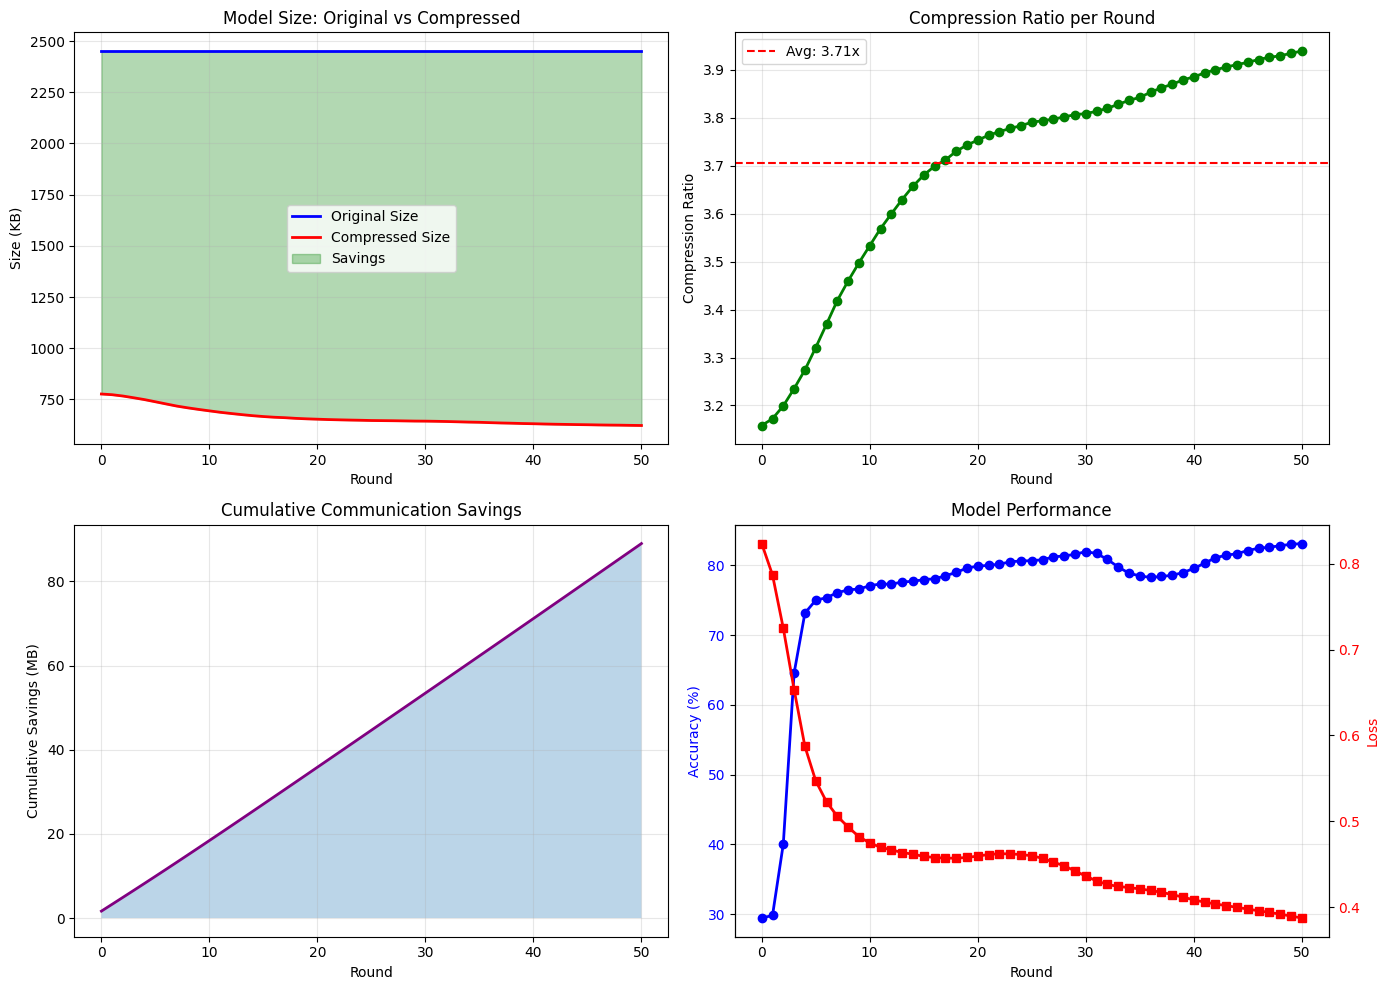

Model saved to 'compressed_fl_mtkd_noniid_unbalanced.h5'


/home/maxwellsam/Compression_Model_FL_MTKD/.FL_MTKD/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [429]:
# Print compression summary
compression_tracker.print_summary()

# Plot compression metrics
compression_tracker.plot_metrics()

# Save the compressed model
temp_model.save('compressed_fl_mtkd_noniid_unbalanced.h5')
print("Model saved to 'compressed_fl_mtkd_noniid_unbalanced.h5'")


COMPRESSED FL-MTKD EVALUATION ON INDIVIDUAL DATASETS

----- Compressed Model Evaluation on Dataset 1 -----
9/9 [==============================] - 0s 20ms/step


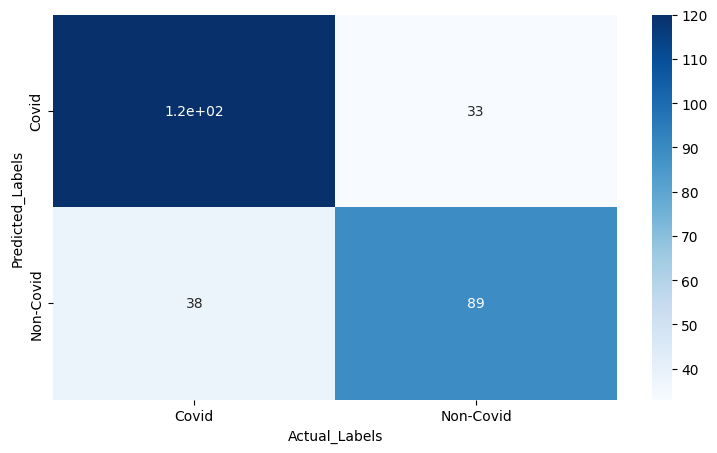

test accuracy = 74.64285714285714%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.7464
Precision: 0.7479
Recall: 0.7464
F1 Score: 0.7469

----- Compressed Model Evaluation on Dataset 2 -----
25/25 [==============================] - 1s 20ms/step


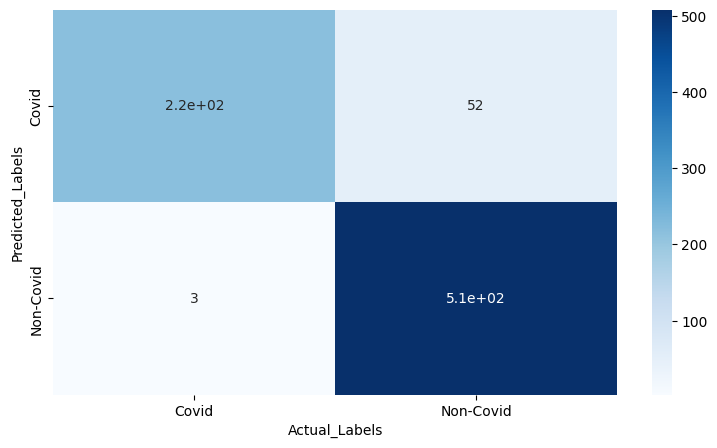

test accuracy = 92.94871794871796%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.9295
Precision: 0.9413
Recall: 0.9295
F1 Score: 0.9314

----- Compressed Model Evaluation on Dataset 3 -----
79/79 [==============================] - 2s 18ms/step


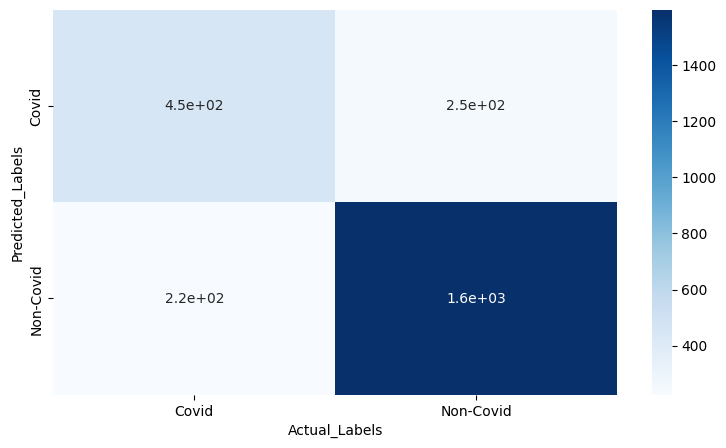

test accuracy = 81.24504361617764%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.8125
Precision: 0.8146
Recall: 0.8125
F1 Score: 0.8134


In [430]:
# Evaluate compressed model on individual client datasets
print("\n" + "="*70)
print("COMPRESSED FL-MTKD EVALUATION ON INDIVIDUAL DATASETS")
print("="*70)

compressed_model_final = tf.keras.models.load_model('compressed_fl_mtkd_noniid_unbalanced.h5')

print('\n----- Compressed Model Evaluation on Dataset 1 -----')
getModelEvaluation(compressed_model_final, test_features_dataset1_fed, test_labels_dataset1_fed)

print('\n----- Compressed Model Evaluation on Dataset 2 -----')
getModelEvaluation(compressed_model_final, test_features_dataset2_fed, test_labels_dataset2_fed)

print('\n----- Compressed Model Evaluation on Dataset 3 -----')
getModelEvaluation(compressed_model_final, test_features_dataset3_fed, test_labels_dataset3_fed)

### Comparison: Original FL-MTKD vs Compressed FL-MTKD

Compare the performance and communication efficiency of:
1. **Original FL-MTKD**: Without compression
2. **Compressed FL-MTKD**: With entropy-penalized reparameterization

In [431]:
# Comparison: Original vs Compressed FL-MTKD
print("="*70)
print("COMPARISON: ORIGINAL FL-MTKD vs COMPRESSED FL-MTKD")
print("="*70)

# Calculate model sizes
original_model = tf.keras.models.load_model('gsm_noniid_unbalanced.h5')
compressed_model = tf.keras.models.load_model('compressed_fl_mtkd_noniid_unbalanced.h5')

# Get original model weights size
original_weights = original_model.get_weights()
original_size_bytes = sum(w.nbytes for w in original_weights)

# Compress and get compressed size
compressed_bytes, compression_stats = fl_compressor.compress_model_weights(original_weights)

print(f"\n--- Model Size Comparison ---")
print(f"Original FL-MTKD model size: {original_size_bytes / 1024:.2f} KB")
print(f"Compressed FL-MTKD model size: {compression_stats['compressed_size_kb']:.2f} KB")
print(f"Compression Ratio: {compression_stats['compression_ratio']:.2f}x")
print(f"Bandwidth Reduction: {(1 - compression_stats['compressed_size_kb'] / (original_size_bytes/1024)) * 100:.1f}%")

# Compare accuracy (assuming both experiments ran for 50 rounds)
print(f"\n--- Accuracy Comparison ---")
if 'metrics_nonIID_unbalanced' in dir() and metrics_nonIID_unbalanced['accuracy']:
    original_final_acc = metrics_nonIID_unbalanced['accuracy'][-1]
    print(f"Original FL-MTKD Final Accuracy: {original_final_acc * 100:.2f}%")
else:
    print("Original FL-MTKD: Run the original experiment first")

if metrics_compressed_nonIID_unbalanced['accuracy']:
    compressed_final_acc = metrics_compressed_nonIID_unbalanced['accuracy'][-1]
    print(f"Compressed FL-MTKD Final Accuracy: {compressed_final_acc * 100:.2f}%")

# Communication savings over 50 rounds
print(f"\n--- Communication Savings (50 rounds, 3 clients) ---")
rounds = 50
num_clients = 3
original_comm = rounds * num_clients * 2 * original_size_bytes  # *2 for up+down
compressed_comm = rounds * num_clients * 2 * compression_stats['compressed_size_bytes']

print(f"Original FL-MTKD total communication: {original_comm / (1024*1024):.2f} MB")
print(f"Compressed FL-MTKD total communication: {compressed_comm / (1024*1024):.2f} MB")
print(f"Total Bandwidth Saved: {(original_comm - compressed_comm) / (1024*1024):.2f} MB")
print(f"Percentage Reduction: {(1 - compressed_comm/original_comm) * 100:.1f}%")

print("\n" + "="*70)

COMPARISON: ORIGINAL FL-MTKD vs COMPRESSED FL-MTKD

--- Model Size Comparison ---
Original FL-MTKD model size: 2451.51 KB
Compressed FL-MTKD model size: 725.68 KB
Compression Ratio: 3.38x
Bandwidth Reduction: 70.4%

--- Accuracy Comparison ---
Original FL-MTKD Final Accuracy: 29.40%
Compressed FL-MTKD Final Accuracy: 83.11%

--- Communication Savings (50 rounds, 3 clients) ---
Original FL-MTKD total communication: 718.22 MB
Compressed FL-MTKD total communication: 212.60 MB
Total Bandwidth Saved: 505.61 MB
Percentage Reduction: 70.4%



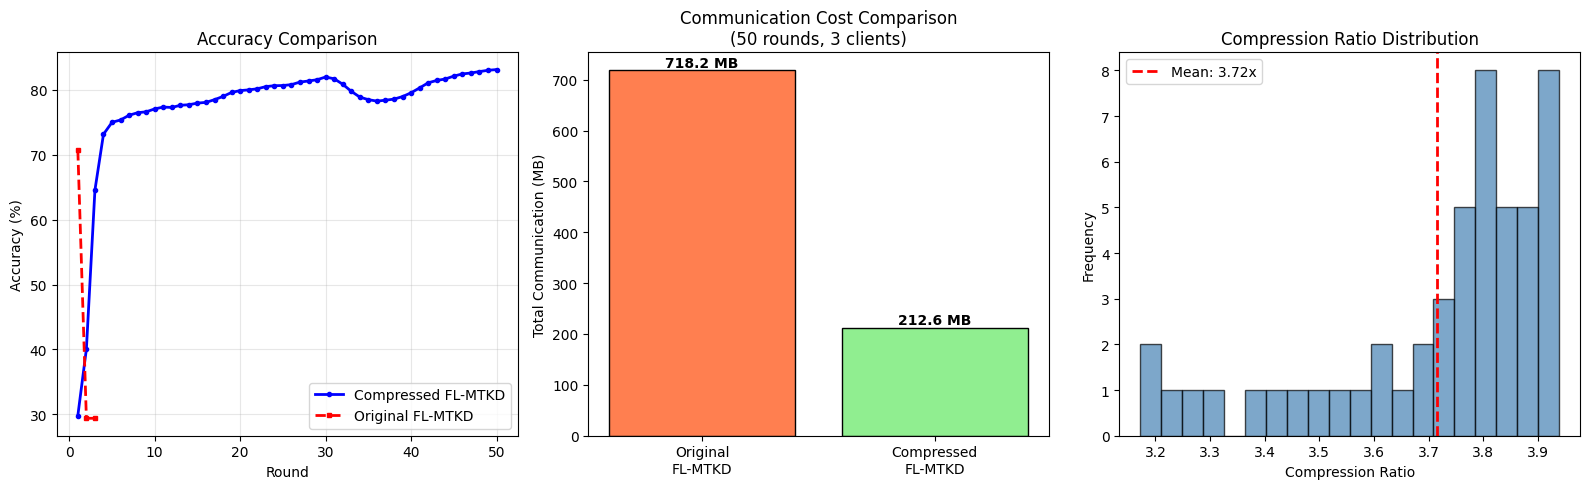


Visualization saved to 'fl_mtkd_comparison.png'


In [432]:
# Visualization: Original vs Compressed FL-MTKD Performance
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Accuracy comparison over rounds
ax1 = axes[0]
rounds_list = list(range(1, len(metrics_compressed_nonIID_unbalanced['accuracy']) + 1))
ax1.plot(rounds_list, [a * 100 for a in metrics_compressed_nonIID_unbalanced['accuracy']], 
         'b-', linewidth=2, label='Compressed FL-MTKD', marker='o', markersize=3)

# If original metrics exist, plot them too
if 'metrics_nonIID_unbalanced' in dir() and metrics_nonIID_unbalanced['accuracy']:
    ax1.plot(range(1, len(metrics_nonIID_unbalanced['accuracy']) + 1), 
             [a * 100 for a in metrics_nonIID_unbalanced['accuracy']], 
             'r--', linewidth=2, label='Original FL-MTKD', marker='s', markersize=3)

ax1.set_xlabel('Round')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Communication cost comparison (bar chart)
ax2 = axes[1]
methods = ['Original\nFL-MTKD', 'Compressed\nFL-MTKD']
comm_costs = [original_comm / (1024*1024), compressed_comm / (1024*1024)]
colors = ['coral', 'lightgreen']
bars = ax2.bar(methods, comm_costs, color=colors, edgecolor='black')
ax2.set_ylabel('Total Communication (MB)')
ax2.set_title('Communication Cost Comparison\n(50 rounds, 3 clients)')

# Add value labels on bars
for bar, cost in zip(bars, comm_costs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{cost:.1f} MB', ha='center', va='bottom', fontweight='bold')

# Plot 3: Compression ratio distribution
ax3 = axes[2]
if metrics_compressed_nonIID_unbalanced['compression_ratio']:
    ax3.hist(metrics_compressed_nonIID_unbalanced['compression_ratio'], bins=20, 
             color='steelblue', edgecolor='black', alpha=0.7)
    ax3.axvline(x=np.mean(metrics_compressed_nonIID_unbalanced['compression_ratio']),
                color='red', linestyle='--', linewidth=2,
                label=f"Mean: {np.mean(metrics_compressed_nonIID_unbalanced['compression_ratio']):.2f}x")
    ax3.set_xlabel('Compression Ratio')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Compression Ratio Distribution')
    ax3.legend()

plt.tight_layout()
plt.savefig('fl_mtkd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to 'fl_mtkd_comparison.png'")

## Summary: Scalable Model Compression in FL-MTKD

### Implementation Summary

This notebook implements **Scalable Model Compression via Entropy-Penalized Reparameterization** for the FL-MTKD framework, as proposed in the project document. Key components implemented:

1. **Entropy Model (`EntropyModel`)**: Estimates bit-rate of latent parameters for compression penalty
2. **Compressible Layers (`CompressibleDense`, `CompressibleConv2D`)**: Reparameterize weights as w = θ × scale
3. **Model Compressor (`ModelCompressor`)**: Handles quantization and entropy coding for transmission
4. **Compressed Distiller (`Distiller_Compressed_MTKD`)**: Adds entropy penalty to the training loss
5. **Compressed FL-MTKD (`FL_MTKD_Compressed`)**: Complete TFF iterative process with compression

### Loss Function

The modified loss function includes the entropy penalty:

```
L_total = α × L_CE + (1-α) × L_KD + λ × H(θ)
```

Where:
- **L_CE**: Cross-entropy loss for classification
- **L_KD**: Knowledge distillation loss (KL divergence with temperature scaling)
- **H(θ)**: Entropy of latent parameters (compression penalty)
- **λ**: Rate-distortion tradeoff parameter (tune for compression vs accuracy)

### Compression Pipeline

```
Client Side:
  Train with entropy penalty → Quantize weights → Entropy code → Send compressed

Server Side:
  Receive compressed → Decompress → Aggregate → Compress → Broadcast
```

### Key Parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| λ (lambda_rate) | 0.001 | Entropy penalty strength (higher = more compression) |
| Quantization bits | 8 | Number of bits for weight quantization |
| α (alpha) | 0.6 | Weight for CE loss vs KD loss |
| Temperature | 10 | Temperature for knowledge distillation |

### Expected Benefits

1. **Reduced Communication Overhead**: Typically 2-4x compression ratio
2. **Improved Scalability**: Smaller updates enable more clients
3. **Maintained Accuracy**: Entropy penalty encourages compressible but accurate weights
4. **Real-World Applicability**: Better suited for bandwidth-constrained environments

### References

1. Oktay, D., Ballé, J., Singh, S., & Shrivastava, A. (2020). "Scalable Model Compression by Entropy-Penalized Reparameterization." ICLR 2020.

### federated_train_data_nonIID_unbalanced

In [433]:
from tqdm import tqdm
import time
teacher_weights = [[0.7, 0.15,0.15],[0.15, 0.7,0.15], [0.15, 0.15,0.7]]
teacher_model_select = [[2.0,10.0,10.0],[10.0,2.0,10.0], [10.0,10.0,2.0]]
metrics_nonIID_unbalanced = {'loss':[],'accuracy':[]}
server_state = FL_MTKD.initialize()
for round in tqdm(range(50)):
    server_state = FL_MTKD.next(server_state, federated_train_data_sampled,teacher_weights,teacher_model_select)
    temp_model_nonIID_unbalanced = evaluate(server_state,combined_test_data)
    loss = list(temp_model_nonIID_unbalanced.get_metrics_result().values())[0].numpy()
    accuracy = list(temp_model_nonIID_unbalanced.get_metrics_result().values())[1].numpy()
    metrics_nonIID_unbalanced['loss'].append(loss)
    metrics_nonIID_unbalanced['accuracy'].append(accuracy)
#temp_model = evaluate(server_state,combined_test_data)

  0%|          | 0/50 [00:00<?, ?it/s]2026-01-28 19:27:23.463940: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 4
2026-01-28 19:27:23.464056: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-01-28 19:27:23.468300: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5611 MB memory:  -> device: 0, name: Quadro RTX 5000, pci bus id: 0000:19:00.0, compute capability: 7.5
2026-01-28 19:27:23.468552: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 14753 MB memory:  -> device: 1, name: Quadro RTX 5000, pci bus id: 0000:1a:00.0, compute capability: 7.5
2026-01-28 19:27:23.468792: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 14753 MB memory:  -> device: 2, name: Quadro RTX 5000

180/180 [==============================] - 3s 13ms/step - loss: 0.6395 - categorical_accuracy: 0.7060


  2%|▏         | 1/50 [12:30<10:12:42, 750.25s/it]

180/180 [==============================] - 3s 12ms/step - loss: 0.8384 - categorical_accuracy: 0.7060


  4%|▍         | 2/50 [19:01<7:11:19, 539.16s/it] 

...

 96%|█████████▌| 48/50 [5:09:07<12:36, 378.41s/it]

180/180 [==============================] - 3s 12ms/step - loss: 4.0124 - categorical_accuracy: 0.7060


 98%|█████████▊| 49/50 [5:15:34<06:21, 381.00s/it]

180/180 [==============================] - 3s 13ms/step - loss: 4.0147 - categorical_accuracy: 0.7060


100%|██████████| 50/50 [5:22:01<00:00, 386.44s/it]


In [434]:
temp_model_nonIID_unbalanced.save('gsm_noniid_unbalanced.h5')
temp_model_nonIID_unbalanced = tf.keras.models.load_model('gsm_noniid_unbalanced.h5')

/home/maxwellsam/Compression_Model_FL_MTKD/.FL_MTKD/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


--------------------- Student Model Evaluation on Dataset1 ------------------------
9/9 [==============================] - 0s 18ms/step


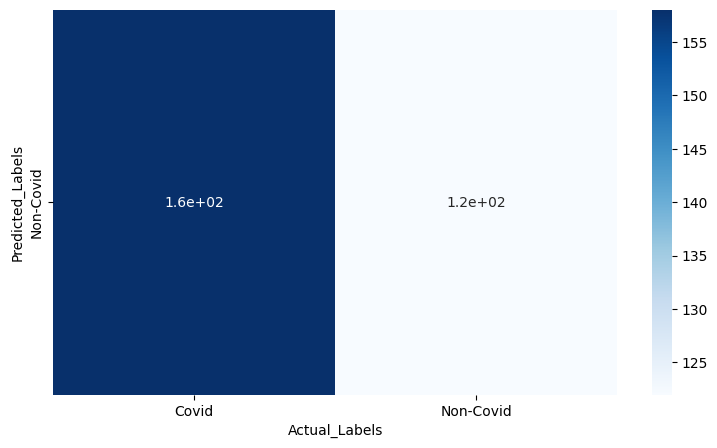

test accuracy = 43.57142857142857%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.4357
Precision: 0.1898
Recall: 0.4357
F1 Score: 0.2645
--------------------- Student Model Evaluation on Dataset2 ------------------------
25/25 [==============================] - 1s 19ms/step


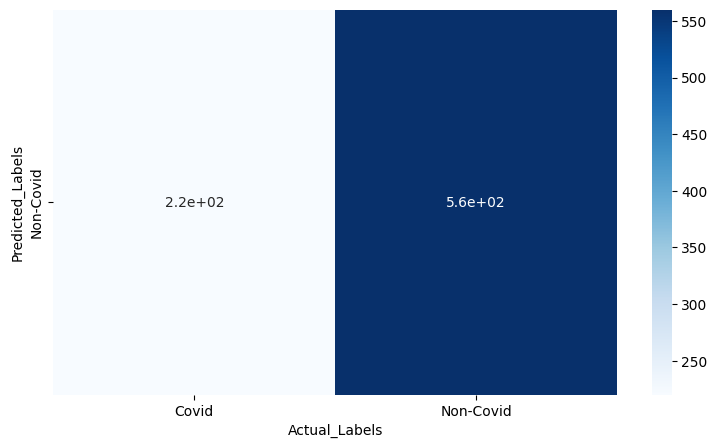

test accuracy = 71.7948717948718%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.7179
Precision: 0.5155
Recall: 0.7179
F1 Score: 0.6001
--------------------- Student Model Evaluation on Dataset3 ------------------------
79/79 [==============================] - 2s 18ms/step


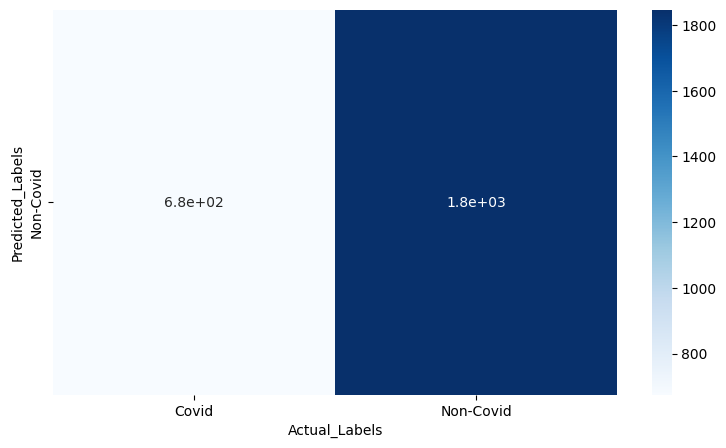

test accuracy = 73.23552735923869%
-------------------------------------------------------------------------------------------------
Model Metrics
Accuracy: 0.7324
Precision: 0.5363
Recall: 0.7324
F1 Score: 0.6192


In [435]:
print('--------------------- Student Model Evaluation on Dataset1 ------------------------')
getModelEvaluation(temp_model_nonIID_unbalanced,test_features_dataset1_fed,test_labels_dataset1_fed)
print('--------------------- Student Model Evaluation on Dataset2 ------------------------')
getModelEvaluation(temp_model_nonIID_unbalanced,test_features_dataset2_fed,test_labels_dataset2_fed)
print('--------------------- Student Model Evaluation on Dataset3 ------------------------')
getModelEvaluation(temp_model_nonIID_unbalanced,test_features_dataset3_fed,test_labels_dataset3_fed)

$(75.357 + 89.743 + 73.880)/3 = 79$